## Phase 1: Target Audit & Data Integrity

In [15]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

if Path.cwd().name == "notebooks": 
    os.chdir("..")

df = pl.read_parquet("data/raw/dataset.parquet")
Path("reports/figures").mkdir(parents=True, exist_ok=True)
print(df.shape)
print(df.dtypes[:10])
print(df["target"].value_counts())

(442961, 78)
[Int64, Float64, String, Float64, Float64, Float64, Int64, Int64, Int64, Float64]
shape: (2, 2)
┌────────┬────────┐
│ target ┆ count  │
│ ---    ┆ ---    │
│ i64    ┆ u32    │
╞════════╪════════╡
│ 1      ┆ 166200 │
│ 0      ┆ 276761 │
└────────┴────────┘


### 1A: Target Distribution

In [7]:
def plot_target_distribution(df: pl.DataFrame, save_dir: str = "reports/figures") -> None:
    """
    Draw a dual-panel figure:
    - Left panel: Donut chart of target=0 (Non-Default) vs target=1 (Default)
      with percentage labels and absolute counts in the legend.
    - Right panel: Horizontal bar comparing class counts on log scale.
    Use seaborn style: "whitegrid". Title: "Phase 1A — Target Class Distribution"
    Save as: reports/figures/phase1a_target_distribution.png (dpi=150)
    """
    try:
        if "target" not in df.columns:
            print("Error: 'target' column not found.")
            return
            
        sns.set_style("whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle("Phase 1A — Target Class Distribution", fontsize=16)
        
        counts = df["target"].value_counts().sort("target").to_pandas()
        counts_dict = dict(zip(counts["target"], counts["count"]))
        
        labels = ["Non-Default (0)", "Default (1)"]
        sizes = [counts_dict.get(0, 0), counts_dict.get(1, 0)]
        
        # Left panel: Donut chart
        wedges, texts, autotexts = axes[0].pie(sizes, autopct='%1.1f%%', startangle=90, 
                                               wedgeprops=dict(width=0.4), colors=["#4C72B0", "#C44E52"])
        axes[0].legend(wedges, [f"{l}: {s:,}" for l, s in zip(labels, sizes)], 
                       title="Classes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
        axes[0].set_title("Proportion of Classes")
        
        # Right panel: Horizontal bar on log scale
        sns.barplot(x=sizes, y=labels, ax=axes[1], hue=labels, palette=["#4C72B0", "#C44E52"], legend=False)
        axes[1].set_xscale("log")
        axes[1].set_xlabel("Count (Log Scale)")
        axes[1].set_title("Absolute Counts (Log Scale)")
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase1a_target_distribution.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error in plot_target_distribution: {e}")

### 1B: Temporal Split

In [8]:
def plot_temporal_split(df: pl.DataFrame, split_ts: int = 1_672_531_200, 
                         save_dir: str = "reports/figures") -> None:
    """
    The dataset contains both Train (before 2023) and Test (after 2023), 
    separated by Unix timestamp 1,672,531,200.
    """
    try:
        df_ts = df.with_columns([
            pl.when(pl.col("borrow_timestamp") < split_ts).then(pl.lit("Train")).otherwise(pl.lit("Test")).alias("split"),
            pl.from_epoch("borrow_timestamp", time_unit="s").alias("borrow_datetime")
        ])
        
        split_stats = df_ts.group_by("split").agg([
            pl.len().alias("wallet_count"),
            pl.col("target").mean().alias("default_rate")
        ]).to_pandas().set_index("split")
        
        train_size = split_stats.loc["Train", "wallet_count"] if "Train" in split_stats.index else 0
        test_size = split_stats.loc["Test", "wallet_count"] if "Test" in split_stats.index else 0
        train_pd = split_stats.loc["Train", "default_rate"] if "Train" in split_stats.index else 0.0
        test_pd = split_stats.loc["Test", "default_rate"] if "Test" in split_stats.index else 0.0
        
        print(f"Train size: {train_size:,} | Test size: {test_size:,}")
        print(f"Train default rate: {train_pd:.2%} | Test default rate: {test_pd:.2%}")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Left: Stacked bar
        counts_df = df_ts.group_by(["split", "target"]).len().to_pandas()
        counts_pivot = counts_df.pivot(index="split", columns="target", values="len").fillna(0)
        # Ensure order
        counts_pivot = counts_pivot.reindex(["Train", "Test"])
        counts_pivot.plot(kind="bar", stacked=True, color=["#4C72B0", "#C44E52"], ax=axes[0])
        axes[0].set_title("Wallet Count per Split")
        axes[0].set_ylabel("Count")
        axes[0].legend(["Non-Default (0)", "Default (1)"], title="Target")
        
        # Right: Line plot
        monthly_df = df_ts.with_columns(
            pl.col("borrow_datetime").dt.truncate("1mo").alias("month")
        ).group_by("month").agg(pl.col("target").mean().alias("default_rate")).sort("month").to_pandas()
        
        axes[1].plot(monthly_df["month"], monthly_df["default_rate"], marker='o', linestyle='-', color="#555555")
        
        import datetime
        split_dt = datetime.datetime.fromtimestamp(split_ts, datetime.timezone.utc).replace(tzinfo=None)
        axes[1].axvline(x=split_dt, color='red', linestyle='--', label="Train | Test")
        axes[1].annotate("Train | Test", xy=(split_dt, axes[1].get_ylim()[1]), 
                         xytext=(5, -15), textcoords="offset points", color="red")
                         
        axes[1].set_title("Monthly Default Rate")
        axes[1].set_ylabel("Default Rate")
        axes[1].legend()
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase1b_temporal_split.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error in plot_temporal_split: {e}")

### 1C: Missing Data

In [9]:
def audit_missing_data(df: pl.DataFrame, save_dir: str = "reports/figures") -> pl.DataFrame:
    try:
        null_counts = df.null_count().to_pandas().iloc[0]
        total_rows = len(df)
        null_pct = (null_counts / total_rows) * 100
        
        audit_df = pd.DataFrame({
            "column_name": null_counts.index,
            "null_count": null_counts.values,
            "null_pct": null_pct.values
        }).sort_values("null_pct", ascending=False)
        
        missing_df = audit_df[audit_df["null_pct"] > 0]
        
        if missing_df.empty:
            print("\033[92mSuccess: NO columns have missing values!\033[0m")
        else:
            colors = ['red' if pct > 5 else 'orange' if pct >= 1 else 'green' for pct in missing_df['null_pct']]
            
            plt.figure(figsize=(10, max(6, len(missing_df)*0.3)))
            sns.barplot(x="null_pct", y="column_name", data=missing_df, palette=colors, hue="column_name", legend=False)
            plt.title("Missing Data Audit (Columns with >0% nulls)")
            plt.xlabel("Null Percentage (%)")
            plt.ylabel("Column")
            plt.tight_layout()
            plt.savefig(f"{save_dir}/phase1c_missing_data_audit.png", dpi=150)
            plt.show()
            
        return pl.DataFrame(audit_df)
    except Exception as e:
        print(f"Error in audit_missing_data: {e}")
        return pl.DataFrame()

### Summary

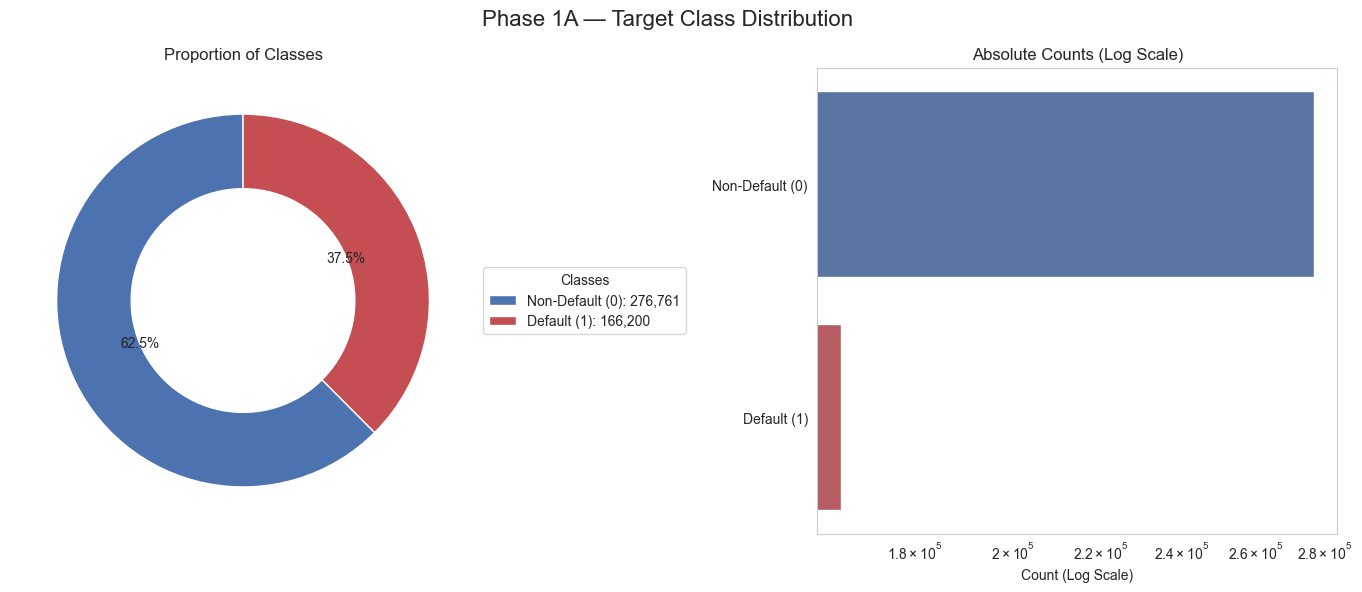

Train size: 402,754 | Test size: 40,207
Train default rate: 38.58% | Test default rate: 26.86%


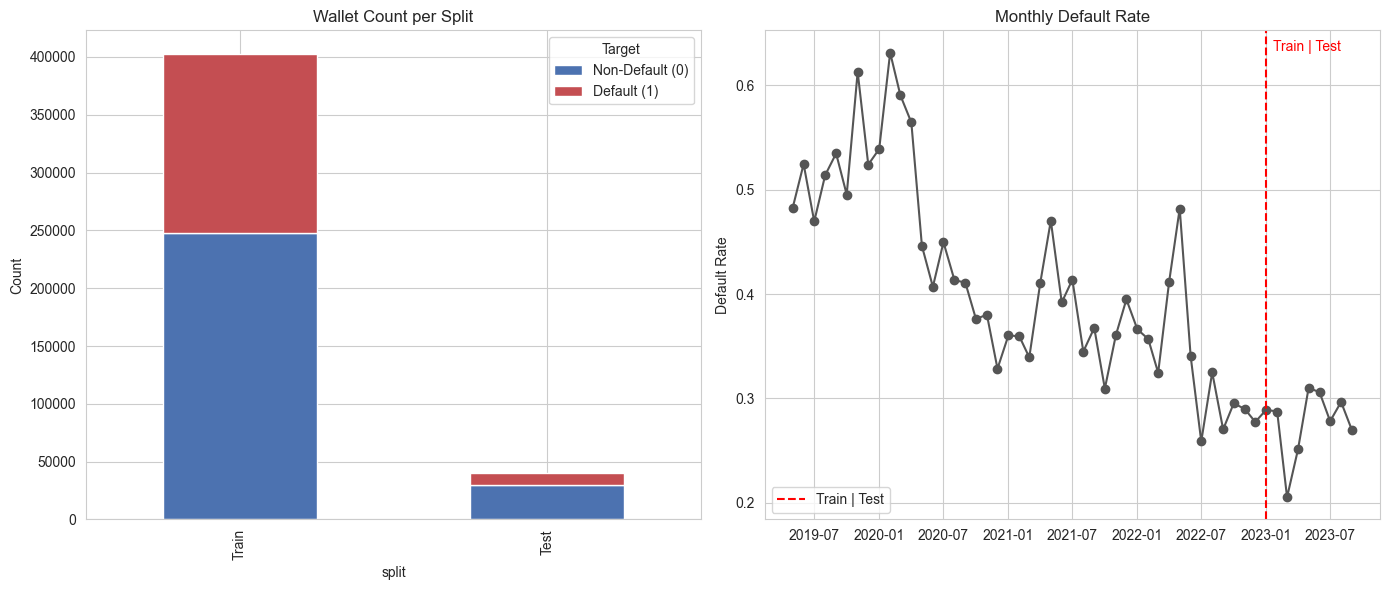

Success: NO columns have missing values!

Phase 1 COMPLETE. Total wallets: 442,961 | Train: 402,754 (PD=38.58%) | Test: 40,207 (PD=26.86%) | Class Imbalance Ratio: 1:1.7


In [10]:
plot_target_distribution(df)
plot_temporal_split(df)
audit_df = audit_missing_data(df)

try:
    total_wallets = len(df)
    df_ts = df.with_columns(pl.when(pl.col("borrow_timestamp") < 1_672_531_200).then(pl.lit("Train")).otherwise(pl.lit("Test")).alias("split"))
    stats = df_ts.group_by("split").agg([pl.len().alias("count"), pl.col("target").mean().alias("pd")]).to_pandas().set_index("split")
    
    train_count = stats.loc["Train", "count"] if "Train" in stats.index else 0
    test_count = stats.loc["Test", "count"] if "Test" in stats.index else 0
    train_pd = stats.loc["Train", "pd"] * 100 if "Train" in stats.index else 0
    test_pd = stats.loc["Test", "pd"] * 100 if "Test" in stats.index else 0
    
    target_counts = df["target"].value_counts().to_pandas().set_index("target")["count"].to_dict()
    minority = min(target_counts.values())
    majority = max(target_counts.values())
    ratio = majority / minority if minority > 0 else 0
    
    print(f"\nPhase 1 COMPLETE. Total wallets: {total_wallets:,} | Train: {train_count:,} (PD={train_pd:.2f}%) | Test: {test_count:,} (PD={test_pd:.2f}%) | Class Imbalance Ratio: 1:{ratio:.1f}")
except Exception as e:
    pass

## Phase 2: Wallet Behavioral DNA & Gas Economics

### 2A: Transaction Activity Split by Target

In [11]:
def plot_tx_activity_by_target(df: pl.DataFrame, save_dir: str = "reports/figures") -> None:
    """
    Create a 2x2 grid of KDE plots, one subplot per variable:
    [incoming_tx_count, outgoing_tx_count, net_incoming_tx_count, wallet_age]
    """
    try:
        import numpy as np
        sns.set_style("whitegrid")
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle("Phase 2A — Transaction Behavioral Signature by Default Status", fontsize=16)
        
        variables = ["incoming_tx_count", "outgoing_tx_count", "net_incoming_tx_count", "wallet_age"]
        axes = axes.flatten()
        
        df_pd = df.select(["target"] + variables).to_pandas().fillna(0)
        
        for i, var in enumerate(variables):
            ax = axes[i]
            
            df_pd[f"log1p_{var}"] = np.log1p(df_pd[var])
            
            sns.kdeplot(data=df_pd[df_pd["target"] == 0], x=f"log1p_{var}", color="blue", alpha=0.6, fill=True, ax=ax)
            sns.kdeplot(data=df_pd[df_pd["target"] == 1], x=f"log1p_{var}", color="red", alpha=0.6, fill=True, ax=ax)
            
            med_0 = df_pd[df_pd["target"] == 0][var].median()
            med_1 = df_pd[df_pd["target"] == 1][var].median()
            
            log_med_0 = np.log1p(med_0)
            log_med_1 = np.log1p(med_1)
            
            ax.axvline(log_med_0, color="blue", linestyle="--", alpha=0.8)
            ax.axvline(log_med_1, color="red", linestyle="--", alpha=0.8)
            
            ax.set_xlabel(f"log1p({var})")
            ax.legend(title="Target", labels=[f"Non-Default (median={med_0:.2f})", f"Default (median={med_1:.2f})"])
            
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase2a_tx_activity_by_target.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error in plot_tx_activity_by_target: {e}")

### 2B: Gas Economics Fingerprint

In [12]:
def plot_gas_economics(df: pl.DataFrame, save_dir: str = "reports/figures") -> None:
    """
    Create a 1x2 figure for Gas Cost per TX and Gas Spend vs Transaction Volume with synchronized colors.
    """
    try:
        import os
        import numpy as np
        import matplotlib.pyplot as plt
        import seaborn as sns

        os.makedirs(save_dir, exist_ok=True)

        df_pd = df.select(["target", "avg_gas_paid_per_tx_eth", "total_gas_paid_eth", "incoming_tx_count"]).to_pandas().fillna(0)

        df_pd["target"] = df_pd["target"].map({0: "0: Safe", 1: "1: Default"}).astype(str)
        
        # Using log1p with clipping to handle zeros and negative values gracefully
        df_pd["log1p_avg_gas"] = np.log1p(np.clip(df_pd["avg_gas_paid_per_tx_eth"], 0, None))
        df_pd["log1p_total_gas"] = np.log1p(np.clip(df_pd["total_gas_paid_eth"], 0, None))
        df_pd["log1p_inc_tx"] = np.log1p(np.clip(df_pd["incoming_tx_count"], 0, None))
        
        # Define a consistent color palette for both plots
        custom_palette = {"0: Safe": "#4C72B0", "1: Default": "#DD5A5A"}
        target_order = ["0: Safe", "1: Default"]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle("Phase 2B — Gas Economics Fingerprint", fontsize=16, fontweight='bold')
        
        # LEFT PANEL: VIOLIN PLOT 
        sns.violinplot(
            data=df_pd, x="target", y="log1p_avg_gas", hue="target", 
            hue_order=target_order, order=target_order, inner="quartile", 
            palette=custom_palette, legend=False, ax=axes[0]
        )
        axes[0].set_title("Gas Cost per TX: Default vs Non-Default")
        axes[0].set_xlabel("Target Status")
        axes[0].set_ylabel("log1p(avg_gas_paid_per_tx_eth)")
        
        # RIGHT PANEL: SCATTER PLOT 
        sns.scatterplot(
            data=df_pd, x="log1p_total_gas", y="log1p_inc_tx", hue="target", 
            hue_order=target_order, palette=custom_palette, alpha=0.3, ax=axes[1]
        )
        axes[1].set_title("Gas Spend vs Transaction Volume")
        axes[1].set_xlabel("log1p(total_gas_paid_eth)")
        axes[1].set_ylabel("log1p(incoming_tx_count)")
        # Using move_legend to keep the original color-label mapping intact while repositioning the legend
        sns.move_legend(axes[1], loc="upper left", title="Target Status")
        
        # Notations for Degen Zone
        axes[1].annotate("High Gas + High Activity = DeFi Degen Zone", 
                         xy=(0.95, 0.95), xycoords='axes fraction', 
                         horizontalalignment='right', verticalalignment='top',
                         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
                         
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase2b_gas_economics.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

### 2C: Protocol Diversity Risk Heatmap

In [13]:
def plot_protocol_diversity(df: pl.DataFrame, save_dir: str = "reports/figures") -> None:
    """
    Heatmap of Protocol Diversity vs Default Rate (Binned to 0, 1, 2+)
    """
    try:
        import os
        import numpy as np
        import matplotlib.pyplot as plt
        import seaborn as sns

        os.makedirs(save_dir, exist_ok=True)
        
        # Narrow down the protocol counts into 3 bins: 0, 1, and 2+ to reduce sparsity
        df_binned = df.with_columns([
            pl.when(pl.col("unique_borrow_protocol_count") >= 2).then(pl.lit("2+"))
              .otherwise(pl.col("unique_borrow_protocol_count").cast(pl.Utf8))
              .alias("borrow_bin"),
            pl.when(pl.col("unique_lending_protocol_count") >= 2).then(pl.lit("2+"))
              .otherwise(pl.col("unique_lending_protocol_count").cast(pl.Utf8))
              .alias("lending_bin")
        ])
        
        # Calculate the average default rate for each combination of borrow_bin and lending_bin
        pivot_df = df_binned.group_by(["borrow_bin", "lending_bin"]).agg(
            pl.col("target").mean().alias("default_rate")
        ).to_pandas()
        
        # Turn the long format into a pivot table for heatmap plotting
        pivot_table = pivot_df.pivot(index="borrow_bin", columns="lending_bin", values="default_rate")
        
        # Update the axis labels according to the new bins to eliminate empty NaN cells
        order = ["0", "1", "2+"]
        pivot_table = pivot_table.reindex(index=order, columns=order)
        
        # Proceed with configuring and plotting the Seaborn Heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot_table, annot=True, fmt=".2%", cmap="YlOrRd", 
                    cbar_kws={'label': 'Empirical Probability of Default'})
        plt.title("Phase 2C — Protocol Diversity vs Default Rate Heatmap\n(Cell value = Empirical Probability of Default)", pad=20)
        plt.xlabel("Unique Lending Protocol Count")
        plt.ylabel("Unique Borrow Protocol Count")
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase2c_protocol_diversity_heatmap.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

### Summary Insights

/Users/danganh71/Developer/python/Machine learning I/Project/risk_assessment/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/danganh71/Developer/python/Machine learning I/Project/risk_assessment/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/qt/jfzr797n3d564cp56n2mmjnh0000gn/T/ipykernel_3082/1894507125.py:28: RuntimeWarning: invalid value encountered in log1p
  log_med_0 = np.log1p(med_0)
/var/folders/qt/jfzr797n3d564cp56n2mmjnh0000gn/T/ipykernel_3082/1894507125.py:29: RuntimeWarning: invalid value encountered in log1p
  log_med_1 = np.log1p(med_1)


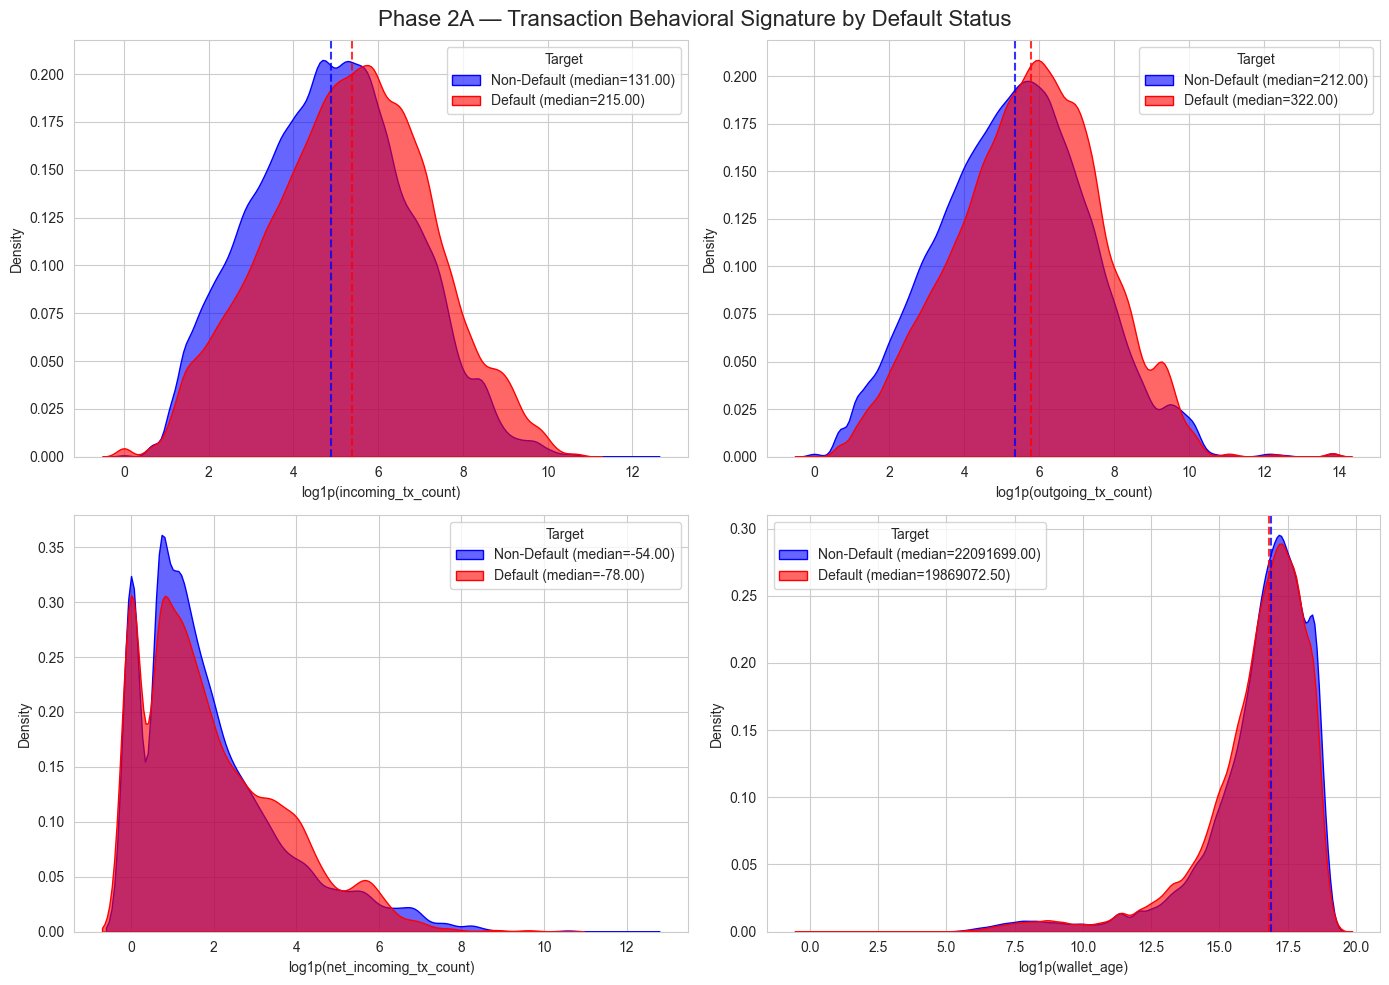

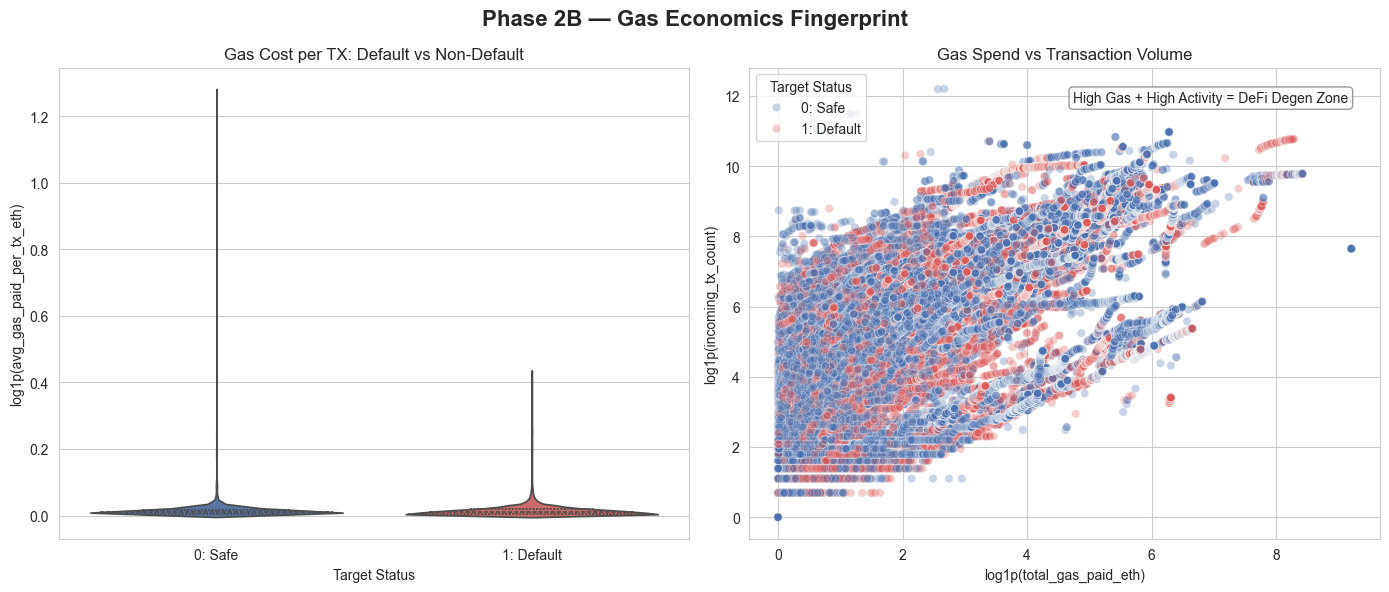

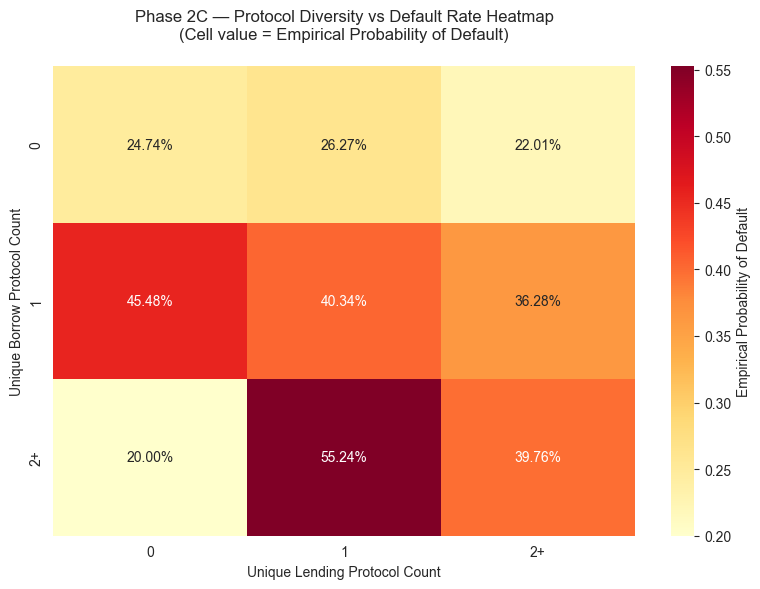


KEY INSIGHT: Defaulted wallets have 1.6x higher median gas spend.
Wallets on 1 lending protocol only have PD = 37.58%.


In [14]:
plot_tx_activity_by_target(df)
plot_gas_economics(df)
plot_protocol_diversity(df)

try:
    med_gas_0 = df.filter(pl.col("target") == 0).select(pl.col("total_gas_paid_eth").median()).item()
    med_gas_1 = df.filter(pl.col("target") == 1).select(pl.col("total_gas_paid_eth").median()).item()
    gas_mult = med_gas_1 / med_gas_0 if med_gas_0 and med_gas_0 > 0 else 0
    
    pd_1_lend = df.filter(pl.col("unique_lending_protocol_count") == 1).select(pl.col("target").mean()).item()
    pd_1_lend_pct = (pd_1_lend * 100) if pd_1_lend is not None else 0
    
    print(f"\nKEY INSIGHT: Defaulted wallets have {gas_mult:.1f}x higher median gas spend.")
    print(f"Wallets on 1 lending protocol only have PD = {pd_1_lend_pct:.2f}%.")
except Exception as e:
    print(f"Error computing summary: {e}")

## Phase 3: ETH Cash Flow & Balance Dynamics

### 3A: Net Cash Flow Waterfall Analysis

In [15]:
def plot_cashflow_waterfall(df: pl.DataFrame, save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        df_pd = df.select(["incoming_tx_sum_eth", "outgoing_tx_sum_eth", "target"]).to_pandas()
        
        df_pd.replace([np.inf, -np.inf], np.nan, inplace=True)
        df_pd.dropna(subset=["incoming_tx_sum_eth", "outgoing_tx_sum_eth"], inplace=True)
        
        df_pd["net_flow_eth"] = df_pd["incoming_tx_sum_eth"] - df_pd["outgoing_tx_sum_eth"]
        
        labels = ["Deep Outflow", "Outflow", "Slight Outflow", "Balanced", 
                  "Slight Inflow", "Inflow", "Strong Inflow"]
        
        df_pd["net_flow_bin"], bins = pd.qcut(df_pd["net_flow_eth"], q=7, labels=False, retbins=True, duplicates='drop')
        
        num_bins = df_pd["net_flow_bin"].nunique()
        actual_labels = labels[:num_bins]
        df_pd["net_flow_bin_label"] = df_pd["net_flow_bin"].map(lambda x: actual_labels[int(x)] if pd.notnull(x) else np.nan)
        
        agg_df = df_pd.groupby("net_flow_bin_label", observed=True).agg(
            wallet_count=("target", "size"),
            default_rate=("target", "mean")
        ).reindex(actual_labels).reset_index()
        
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        sns.barplot(data=agg_df, x="net_flow_bin_label", y="wallet_count", palette="Blues_d", ax=ax1)
        ax1.set_ylabel("Wallet Count", color="blue")
        ax1.set_xlabel("Net ETH Cash Flow")
        ax1.tick_params(axis="y", labelcolor="blue")
        
        ax2 = ax1.twinx()
        ax2.plot(agg_df["net_flow_bin_label"], agg_df["default_rate"], color="red", marker="o", linewidth=2)
        ax2.set_ylabel("Empirical Default Rate", color="red")
        ax2.tick_params(axis="y", labelcolor="red")
        
        max_idx = agg_df["default_rate"].idxmax()
        if pd.notna(max_idx):
            ax2.annotate("Highest Default Zone", 
                         xy=(max_idx, agg_df.loc[max_idx, "default_rate"]),
                         xytext=(max_idx, agg_df.loc[max_idx, "default_rate"] * 1.1),
                         arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                         ha='center')
        
        plt.title("Phase 3A — Net ETH Cash Flow vs Default Rate")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase3a_cashflow_waterfall.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

### 3B: Balance Extremes Box Plot Grid

In [16]:
def plot_balance_extremes(df: pl.DataFrame, save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        def cohen_d(x, y):
            nx = len(x)
            ny = len(y)
            dof = nx + ny - 2
            return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)

        df_pd = df.select(["target", "max_eth_ever", "total_balance_eth", "min_eth_ever"]).to_pandas().fillna(0)
        
        df_pd["log1p_max"] = np.log1p(df_pd["max_eth_ever"])
        df_pd["log1p_total"] = np.log1p(df_pd["total_balance_eth"])
        
        min_offset = abs(df_pd["min_eth_ever"].min()) + 1
        df_pd["log1p_min"] = np.log1p(df_pd["min_eth_ever"] + min_offset)
        
        variables = ["log1p_max", "log1p_total", "log1p_min"]
        titles = ["Max ETH Ever", "Total Balance ETH", "Min ETH Ever"]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle("Phase 3B — ETH Balance Extremes: Non-Default vs Default", fontsize=16)
        
        for i, var in enumerate(variables):
            sns.boxplot(data=df_pd, x="target", y=var, hue="target", palette={0: "#2196F3", 1: "#F44336"}, ax=axes[i], showfliers=False, legend=False)
            axes[i].set_title(titles[i])
            axes[i].set_xlabel("Target")
            axes[i].set_ylabel(var)
            axes[i].annotate("log1p transformed", xy=(0.05, 0.95), xycoords='axes fraction', 
                             fontsize=9, color='gray', ha='left', va='top')
            
            x0 = df_pd[df_pd["target"] == 0][var].values
            x1 = df_pd[df_pd["target"] == 1][var].values
            if len(x0) > 1 and len(x1) > 1:
                d = cohen_d(x1, x0)
                print(f"Cohen's d for {var}: {d:.3f}")
                
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase3b_balance_extremes.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

### 3C: Risky Contract Interaction Scatter

In [17]:
def plot_risky_contract_interaction(df: pl.DataFrame, save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        df_pd = df.select(["target", "risky_tx_count", "risky_sum_outgoing_amount_eth"]).to_pandas().fillna(0)
        
        if len(df_pd) > 5000:
            df_pd = df_pd.sample(5000, random_state=42)
            
        df_pd["log1p_risky_count"] = np.log1p(df_pd["risky_tx_count"])
        df_pd["log1p_risky_amt"] = np.log1p(df_pd["risky_sum_outgoing_amount_eth"])
        
        plt.figure(figsize=(10, 8))
        
        sns.kdeplot(data=df_pd[df_pd["target"] == 0], x="log1p_risky_count", y="log1p_risky_amt", cmap="Blues", fill=True, alpha=0.3)
        sns.kdeplot(data=df_pd[df_pd["target"] == 1], x="log1p_risky_count", y="log1p_risky_amt", cmap="Reds", fill=True, alpha=0.3)
        
        plt.scatter(df_pd["log1p_risky_count"], df_pd["log1p_risky_amt"], 
                    c=df_pd["target"].map({0: 'blue', 1: 'red'}), 
                    alpha=0.4, s=10)
        
        plt.axvline(np.log1p(1), color='black', linestyle='--', label="First Risky TX Threshold")
        
        plt.title("Phase 3C — Risky Contract Exposure Map\nSubtitle: Size of circle - ETH sent to risky contracts")
        plt.xlabel("log1p(risky_tx_count)")
        plt.ylabel("log1p(risky_sum_outgoing_amount_eth)")
        
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase3c_risky_contract_scatter.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

### Phase 3 Summary

/var/folders/qt/jfzr797n3d564cp56n2mmjnh0000gn/T/ipykernel_3082/1336112659.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_df, x="net_flow_bin_label", y="wallet_count", palette="Blues_d", ax=ax1)


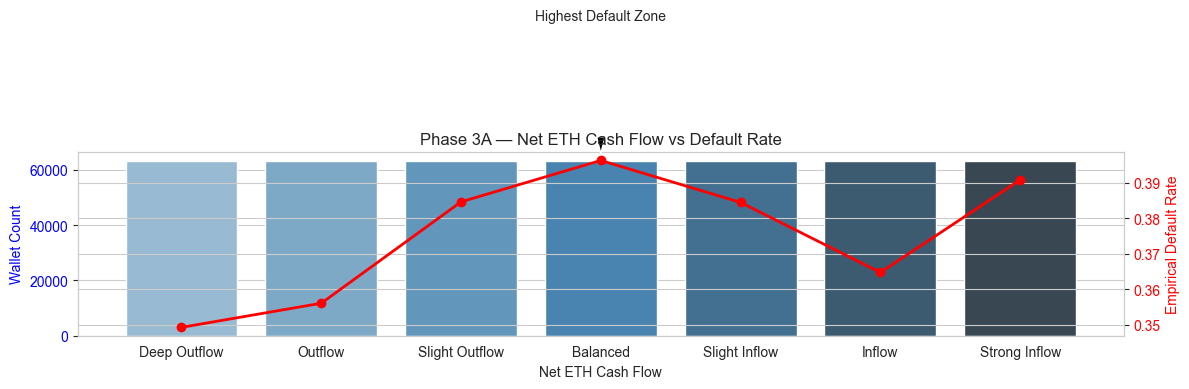

Cohen's d for log1p_max: -0.034
Cohen's d for log1p_total: -0.193
Cohen's d for log1p_min: -0.133


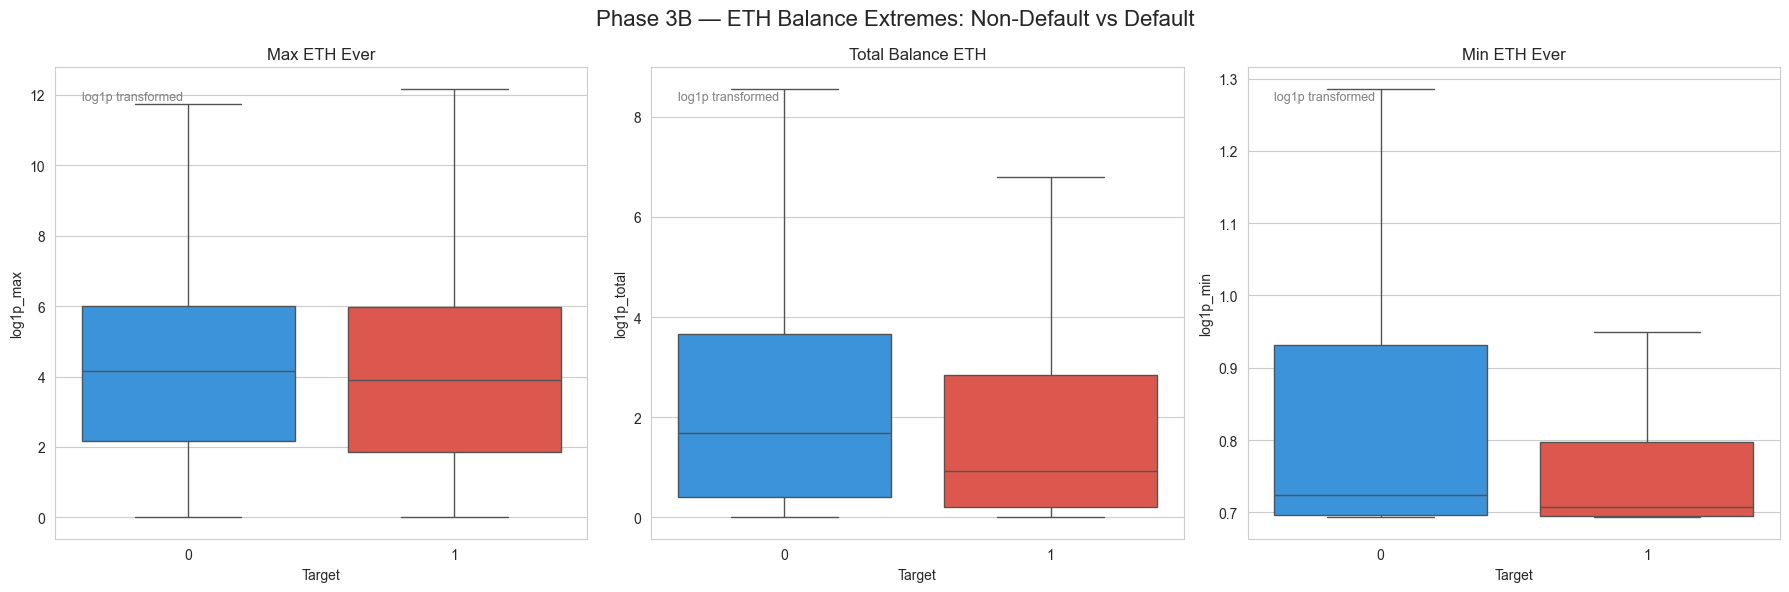

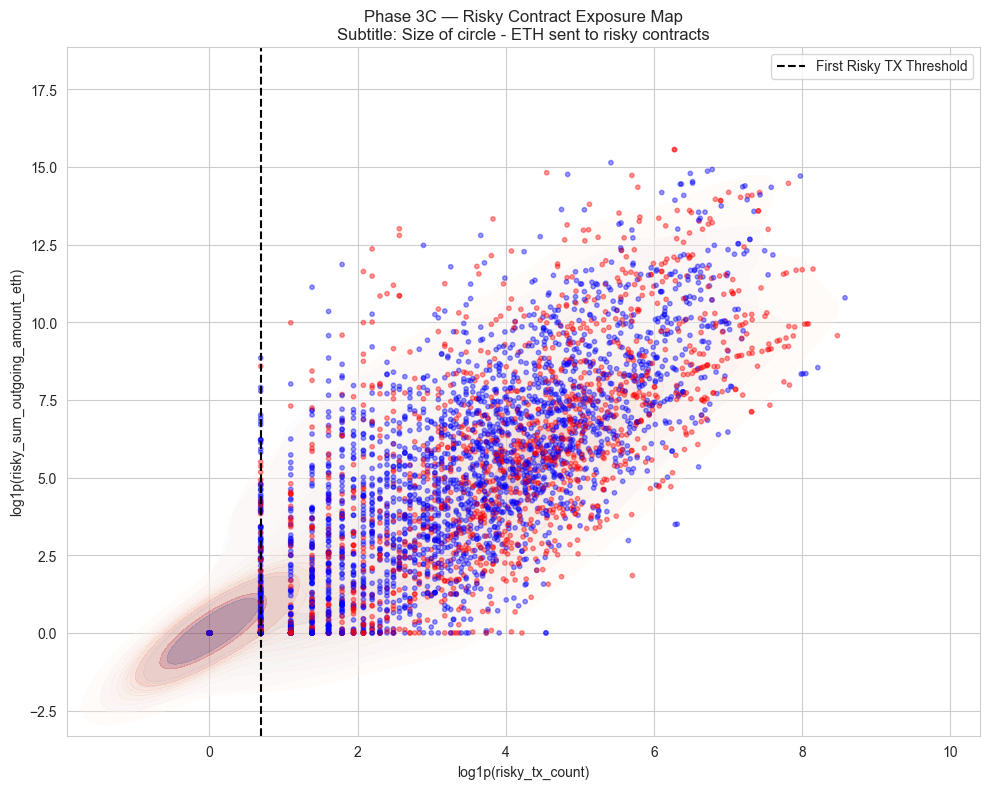

In [18]:
plot_cashflow_waterfall(df)
plot_balance_extremes(df)
plot_risky_contract_interaction(df)

### Phase 4: CREDIT RISK ARCHITECTURE & LIQUIDATION FUNNEL

## Phase 4: Extreme Tail Outlier Audit

### 4A: max_risk_factor Tail Audit

In [19]:
def audit_max_risk_factor_tail(df: pl.DataFrame, cap: float = 100.0, save_dir: str = "reports/figures") -> pl.DataFrame:
    try:
        import os
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        import scipy.stats as stats
        
        os.makedirs(save_dir, exist_ok=True)
        
        percentiles = [0.25, 0.50, 0.75, 0.90, 0.99, 0.999, 0.9999]
        q_vals = [df.select(pl.col("max_risk_factor").quantile(p)).item() for p in percentiles]
        
        print("max_risk_factor Percentile Ladder:")
        for p, q in zip(percentiles, q_vals):
            print(f"{p*100:g}%: {q}")
            
        initial_len = len(df)
        df_clean = df.filter(pl.col("max_risk_factor") <= cap)
        removed_count = initial_len - len(df_clean)
        print(f"Rows removed where max_risk_factor > {cap}: {removed_count}")
        
        target_0 = df_clean.filter(pl.col("target") == 0)["max_risk_factor"].to_numpy()
        target_1 = df_clean.filter(pl.col("target") == 1)["max_risk_factor"].to_numpy()
        
        target_0 = target_0[~np.isnan(target_0)]
        target_1 = target_1[~np.isnan(target_1)]
        
        print(f"Stats target=0 | mean: {np.mean(target_0):.4f}, std: {np.std(target_0):.4f}, skew: {stats.skew(target_0):.4f}, kurtosis: {stats.kurtosis(target_0):.4f}")
        print(f"Stats target=1 | mean: {np.mean(target_1):.4f}, std: {np.std(target_1):.4f}, skew: {stats.skew(target_1):.4f}, kurtosis: {stats.kurtosis(target_1):.4f}")
        
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        df_pd = df_clean.select(["max_risk_factor", "target"]).to_pandas()
        df_pd["log_max_risk_factor"] = np.log1p(df_pd["max_risk_factor"])
        
        df_pd["target"] = df_pd["target"].astype(int)
        label_map = {0: "Non-Default (Safe)", 1: "Default (Risky)"}
        df_pd["Target Status"] = df_pd["target"].map(label_map)
        palette_dict = {"Non-Default (Safe)": "#4C72B0", "Default (Risky)": "#DD5A5A"}
        
        sns.kdeplot(
            data=df_pd, 
            x="log_max_risk_factor", 
            hue="Target Status", 
            fill=True, 
            alpha=0.35, 
            palette=palette_dict, 
            common_norm=False, 
            ax=axes[0]
        )
        
        med_0_log = np.log1p(np.median(target_0)) if len(target_0) > 0 else 0
        med_1_log = np.log1p(np.median(target_1)) if len(target_1) > 0 else 0
        axes[0].axvline(med_0_log, color="#4C72B0", linestyle="--", linewidth=1.5, label=f"Safe Median ({med_0_log:.2f})")
        axes[0].axvline(med_1_log, color="#DD5A5A", linestyle="--", linewidth=1.5, label=f"Risky Median ({med_1_log:.2f})")
        
        axes[0].set_title("4A — log1p(max_risk_factor) Normalized Density", fontsize=12, fontweight="bold")
        axes[0].set_xlabel("log1p(max_risk_factor)")
        axes[0].legend(frameon=True)
        
        sns.boxplot(
            data=df_pd, 
            x="log_max_risk_factor", 
            y="Target Status", 
            hue="Target Status", 
            palette=palette_dict, 
            ax=axes[1], 
            showfliers=True, 
            width=0.5
        )

        if axes[1].get_legend() is not None:
            axes[1].get_legend().remove()
            
        log_cap = np.log1p(cap)
        axes[1].axvline(log_cap, color="#7A4A9E", linestyle=":", linewidth=2, label=f"Log Outlier Cap ({log_cap:.2f})")
        
        axes[1].set_xlim(df_pd["log_max_risk_factor"].min() - 0.2, log_cap + 0.5)
        axes[0].set_xlim(df_pd["log_max_risk_factor"].min() - 0.2, log_cap + 0.5)
        
        axes[1].set_title("4A — log1p(max_risk_factor) Boxplot Overview", fontsize=12, fontweight="bold")
        axes[1].set_xlabel("log1p(max_risk_factor)")
        axes[1].set_ylabel("") 
        axes[1].legend(frameon=True)
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase4a_max_risk_factor_tail_audit.png", dpi=150)
        plt.show()        
        return df_clean
    except Exception as e:
        print(f"Error: {e}")
        raise e

### 4B: Non-linear Risk Cliffs

In [20]:
def detect_risk_cliffs(df: pl.DataFrame,
                        save_dir: str = "reports/figures") -> pl.DataFrame:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        
        df = df.with_columns(pl.col("max_risk_factor").fill_null(0.0))
        
        breaks = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
        labels = ["0.0-0.1","0.1-0.2","0.2-0.3","0.3-0.4","0.4-0.5",
                  "0.5-0.6","0.6-0.7","0.7-0.8","0.8-0.9","0.9-1.0"]
        
        df_cut = df.with_columns(
            pl.col("max_risk_factor").cut(
                breaks=breaks, 
                labels=labels
            ).alias("risk_bucket")
        )
        
        agg_df = df_cut.group_by("risk_bucket", maintain_order=True).agg([
            pl.len().alias("wallet_population"),
            pl.col("target").mean().alias("empirical_pd")
        ])
        
        agg_pd = agg_df.to_pandas()
        
        if "risk_bucket" in agg_pd.columns and isinstance(agg_pd["risk_bucket"].iloc[0], dict):
            # For older polars versions where cut returns a struct
            agg_pd["risk_bucket"] = agg_pd["risk_bucket"].apply(lambda x: x.get("category", str(x)))
            
        agg_pd = agg_pd.set_index("risk_bucket").reindex(labels).reset_index()
        agg_pd["risk_bucket"] = labels
        agg_pd["wallet_population"] = agg_pd["wallet_population"].fillna(0)
        
        agg_pd["pd_diff"] = agg_pd["empirical_pd"].diff().fillna(0)
        mean_abs_diff = agg_pd["pd_diff"].abs().mean()
        
        agg_pd["is_cliff"] = agg_pd["pd_diff"].abs() > (1.5 * mean_abs_diff)
        
        for idx, row in agg_pd[agg_pd["is_cliff"]].iterrows():
            print(f"Risk cliff detected at bin: {row['risk_bucket']}, PD jump: +{row['pd_diff']*100:.2f}%")
            
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        max_pop = agg_pd["wallet_population"].max()
        agg_pd["rel_population"] = agg_pd["wallet_population"] / max_pop if max_pop > 0 else 0
            
        ax1.bar(agg_pd["risk_bucket"], agg_pd["rel_population"], color="lightsteelblue", alpha=0.5, label="Relative Population")
        ax1.set_ylabel("Relative Wallet Population (Max=1)")
        ax1.set_xlabel("Risk Factor Interval")
        ax1.grid(False)
        
        ax2 = ax1.twinx()
        
        x_vals = np.arange(len(agg_pd))
        y_vals = agg_pd["empirical_pd"].values
        
        ax2.plot(x_vals, y_vals, color="steelblue", marker="o", linestyle="-", label="Empirical PD")
        
        for i in range(1, len(agg_pd)):
            if agg_pd["is_cliff"].iloc[i]:
                ax2.plot([x_vals[i-1], x_vals[i]], [y_vals[i-1], y_vals[i]], color="red", linewidth=2.5)
                ax2.annotate(f"cliff +{agg_pd['pd_diff'].iloc[i]*100:.1f}%",
                             xy=(x_vals[i], y_vals[i]),
                             xytext=(x_vals[i]-0.5, y_vals[i]+0.05),
                             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
                             
        ax2.set_ylabel("Empirical PD")
        ax2.grid(True)
        
        plt.title("4B — Non-linear Risk Cliffs: Empirical PD by Risk Factor Interval")
        
        ax1.set_xticks(x_vals)
        ax1.set_xticklabels(agg_pd["risk_bucket"], rotation=45, ha="right")
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase4b_risk_cliffs_inflection.png", dpi=150)
        plt.show()
        
        return pl.DataFrame(agg_pd)
    except Exception as e:
        print(f"Error in detect_risk_cliffs: {e}")
        raise e

### 4C: Liquidation History Deep Dive

In [21]:
def plot_liquidation_deep_dive(df: pl.DataFrame,
                                save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        numeric_cols = ["liquidation_count", "time_since_last_liquidated", 
                        "liquidation_amount_sum_eth", "borrow_amount_sum_eth"]
        df = df.with_columns([pl.col(c).fill_null(0.0) for c in numeric_cols if c in df.columns])
        
        df = df.with_columns(
            pl.when(pl.col("liquidation_count") == 0).then(pl.lit("0 (Never)"))
              .when(pl.col("liquidation_count") == 1).then(pl.lit("1"))
              .when(pl.col("liquidation_count") == 2).then(pl.lit("2"))
              .when(pl.col("liquidation_count") == 3).then(pl.lit("3"))
              .otherwise(pl.lit("4+"))
              .alias("liq_bucket")
        )
        
        summary_df = df.group_by("liq_bucket").agg([
            pl.len().alias("wallet_count"),
            pl.col("target").mean().alias("default_rate")
        ]).to_pandas()
        
        order = ["0 (Never)", "1", "2", "3", "4+"]
        summary_df = summary_df.set_index("liq_bucket").reindex(order).reset_index().fillna(0)
        
        print("Liquidation Bucket Summary:")
        print(summary_df.to_string(index=False))
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig = plt.figure(figsize=(16, 12))
        fig.suptitle("Phase 4C — Liquidation Architecture", fontsize=18)
        
        ax1 = plt.subplot(2, 2, 1)
        ax2 = plt.subplot(2, 2, 2)
        ax3 = plt.subplot(2, 1, 2)
        
        counts_df = df.group_by(["liq_bucket", "target"]).len().to_pandas()
        counts_pivot = counts_df.pivot(index="liq_bucket", columns="target", values="len").reindex(order).fillna(0)
        
        bars = counts_pivot.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD5A5A"], ax=ax1, legend=False)
        ax1.set_title("4C-1 — Wallet Count by Liquidation History")
        ax1.set_xlabel("Liquidation Bucket")
        ax1.set_ylabel("Wallet Count")
        ax1.set_xticklabels(order, rotation=0)
        ax1.legend(["Non-Default (0)", "Default (1)"])
        
        for i, idx in enumerate(order):
            total = counts_pivot.loc[idx].sum()
            dr = summary_df.loc[summary_df["liq_bucket"] == idx, "default_rate"].values[0]
            if total > 0:
                ax1.text(i, total * 1.02, f"{dr*100:.1f}%", ha='center', color='red', fontweight='bold')
                
        df_liq = df.filter(pl.col("liquidation_count") > 0).select(["time_since_last_liquidated", "target"]).to_pandas()
        df_liq["log1p_time"] = np.log1p(df_liq["time_since_last_liquidated"])
        
        sns.kdeplot(data=df_liq[df_liq["target"] == 0], x="log1p_time", fill=True, alpha=0.5, color="#4C72B0", ax=ax2, label="target=0")
        sns.kdeplot(data=df_liq[df_liq["target"] == 1], x="log1p_time", fill=True, alpha=0.5, color="#DD5A5A", ax=ax2, label="target=1")
        
        ax2.set_title("4C-2 — Time Since Last Liquidation (Liquidated Wallets Only)")
        ax2.set_xlabel("log1p(Days Since Last Liquidation)")
        ax2.legend()
        
        sample_size = min(len(df), 6000)
        df_sample = df.sample(sample_size, seed=42) if len(df) > 6000 else df
        df_scatter = df_sample.select(["liquidation_amount_sum_eth", "borrow_amount_sum_eth", "target"]).to_pandas()
        
        df_scatter["log1p_liq_amt"] = np.log1p(df_scatter["liquidation_amount_sum_eth"])
        df_scatter["log1p_borrow_amt"] = np.log1p(df_scatter["borrow_amount_sum_eth"])
        
        scatter = ax3.scatter(df_scatter["log1p_liq_amt"], df_scatter["log1p_borrow_amt"], 
                              c=df_scatter["target"], cmap="coolwarm", alpha=0.35, s=12)
                              
        max_val = max(df_scatter["log1p_liq_amt"].max() if len(df_scatter) else 0, 
                      df_scatter["log1p_borrow_amt"].max() if len(df_scatter) else 0)
        ax3.plot([0, max_val], [0, max_val], color="black", linestyle="--", label="Borrow = Liquidation")
        
        ax3.set_title("4C-3 — Total Liquidation vs Total Borrow Amount")
        ax3.set_xlabel("log1p(liquidation_amount_sum_eth)")
        ax3.set_ylabel("log1p(borrow_amount_sum_eth)")
        ax3.legend()
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase4c_liquidation_deep_dive.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

### 4D: Borrow/Repay Discipline Matrix

In [22]:
def plot_borrow_repay_discipline(df: pl.DataFrame,
                                  save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import matplotlib.cm as cm
        import matplotlib.colors as mcolors
        import seaborn as sns
        
        numeric_cols = ["repay_amount_sum_eth", "borrow_amount_sum_eth", "borrow_repay_diff_eth"]
        df = df.with_columns([pl.col(c).fill_null(0.0) for c in numeric_cols if c in df.columns])
        
        df = df.with_columns(
            (pl.col("repay_amount_sum_eth") / (pl.col("borrow_amount_sum_eth") + 1e-9)).clip(0.0, 2.0).alias("repay_ratio")
        )
        
        breaks = [0.2, 0.5, 0.8, 1.0]
        labels = ["Severe Underpay", "High Risk", "Moderate", "Near Full", "Overpay / Early"]
        
        df = df.with_columns(
            pl.col("repay_ratio").cut(breaks=breaks, labels=labels).alias("repay_bucket")
        )
        
        summary_df = df.group_by("repay_bucket").agg([
            pl.len().alias("wallet_count"),
            pl.col("target").mean().alias("default_rate")
        ]).to_pandas()
        
        if "repay_bucket" in summary_df.columns and len(summary_df) > 0 and isinstance(summary_df["repay_bucket"].iloc[0], dict):
            summary_df["repay_bucket"] = summary_df["repay_bucket"].apply(lambda x: x.get("category", str(x)))
            
        summary_df = summary_df.set_index("repay_bucket").reindex(labels).reset_index()
        summary_df["repay_bucket"] = labels
        summary_df = summary_df.fillna(0)
        
        print("Borrow/Repay Discipline Summary:")
        print(summary_df.to_string(index=False))
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle("Phase 4D — Borrow/Repay Discipline Analysis", fontsize=16)
        
        ax1 = axes[0]
        
        norm = mcolors.Normalize(vmin=0, vmax=1)
        cmap = cm.RdYlGn_r
        colors = [cmap(norm(dr)) for dr in summary_df["default_rate"]]
        
        bars = ax1.bar(summary_df["repay_bucket"], summary_df["wallet_count"], color=colors)
        
        for i, bar in enumerate(bars):
            height = bar.get_height()
            dr = summary_df["default_rate"].iloc[i]
            if height > 0:
                ax1.text(bar.get_x() + bar.get_width() / 2., height * 1.02,
                         f"{dr*100:.1f}%", ha='center', color='red', fontweight='bold')
                         
        ax1.set_title("4D-1 — Wallet Count by Repay Discipline (color = default rate)")
        ax1.set_xlabel("Repay Discipline Category")
        ax1.set_ylabel("Wallet Count")
        ax1.set_xticks(range(len(labels)))
        ax1.set_xticklabels(labels, rotation=30, ha="right")
        
        ax2 = axes[1]
        
        df_box = df.select(["borrow_repay_diff_eth", "target"]).to_pandas()
        df_box["diff_clipped"] = df_box["borrow_repay_diff_eth"].clip(lower=0)
        df_box["log1p_diff"] = np.log1p(df_box["diff_clipped"])
        
        sns.boxplot(data=df_box, x="target", y="log1p_diff", hue="target", palette={0:"#4C72B0", 1:"#DD5A5A"}, ax=ax2, showfliers=False, legend=False)
        ax2.axhline(0, color="black", linestyle="--", label="Break-even (borrow = repay)")
        
        ax2.set_title("4D-2 — Borrow-Repay Gap by Default Status")
        ax2.set_xlabel("Target")
        ax2.set_ylabel("log1p(Borrow - Repay in ETH)")
        ax2.legend()
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase4d_borrow_repay_discipline.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error in plot_borrow_repay_discipline: {e}")

### 4E: Collateral Utilization Heatmap

In [23]:
def plot_collateral_utilization_heatmap(df: pl.DataFrame, save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        numeric_cols = ["borrow_amount_sum_eth", "total_collateral_eth"]
        df = df.with_columns([pl.col(c).fill_null(0.0) for c in numeric_cols if c in df.columns])
        
        df = df.with_columns(
            (pl.col("borrow_amount_sum_eth") / (pl.col("total_collateral_eth") + 1e-9)).clip(0.0, 3.0).alias("LTV_proxy")
        )
        
        df = df.with_columns(
            pl.when(pl.col("risk_factor_above_threshold_daily_count").fill_null(0.0) == 0).then(pl.lit("0 days"))
              .when(pl.col("risk_factor_above_threshold_daily_count").fill_null(0.0) <= 5).then(pl.lit("1-5 days"))
              .when(pl.col("risk_factor_above_threshold_daily_count").fill_null(0.0) <= 20).then(pl.lit("6-20 days"))
              .otherwise(pl.lit("21+ days"))
              .alias("threshold_bin")
        )
        
        df_pd = df.select(["LTV_proxy", "threshold_bin", "target"]).to_pandas()
        
        ltv_bins, ltv_edges = pd.qcut(df_pd["LTV_proxy"], q=8, duplicates="drop", retbins=True)
        num_ltv_bins = len(ltv_edges) - 1
        ltv_labels = [f"LTV D{i+1}" for i in range(num_ltv_bins)]
        
        df_pd["ltv_bin"] = pd.qcut(df_pd["LTV_proxy"], q=8, labels=ltv_labels, duplicates="drop")
        
        pivot_table = df_pd.pivot_table(values="target", index="ltv_bin", columns="threshold_bin", aggfunc="mean")
        
        order_cols = ["0 days", "1-5 days", "6-20 days", "21+ days"]
        actual_cols = [c for c in order_cols if c in pivot_table.columns]
        pivot_table = pivot_table.reindex(columns=actual_cols)
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, ax = plt.subplots(figsize=(10, 7))
        
        sns.heatmap(pivot_table, cmap="RdYlGn_r", annot=True, fmt=".1%", linewidths=0.5,
                    cbar_kws={"label": "Empirical Default Rate"}, ax=ax)
        
        ax.set_xlabel("Risk Factor Threshold Breach Duration")
        ax.set_ylabel("Loan-to-Value Proxy (Quantile Bin)")
        
        fig.suptitle("Phase 4E — LTV Proxy × Threshold Breach Days: Empirical Default Rate", fontsize=13, y=0.96)
        ax.set_title("LTV = borrow / collateral (proxy). Higher LTV combined with more threshold days correlates exponentially with default risk.",
                     fontsize=9, style="italic", pad=15)
        
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.savefig(f"{save_dir}/phase4e_collateral_utilization_heatmap.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error in plot_collateral_utilization_heatmap: {e}")

max_risk_factor Percentile Ladder:
25%: 0.320839130720317
50%: 0.7521871380950073
75%: 0.9028940592968225
90%: 0.9744199234211344
99%: 1.5195647891722686
99.9%: 1000000.0
99.99%: 1000000.0
Rows removed where max_risk_factor > 100.0: 2511
Stats target=0 | mean: 0.5222, std: 0.6741, skew: 48.6773, kurtosis: 3683.5820
Stats target=1 | mean: 0.7907, std: 1.1503, skew: 42.4009, kurtosis: 2058.8587


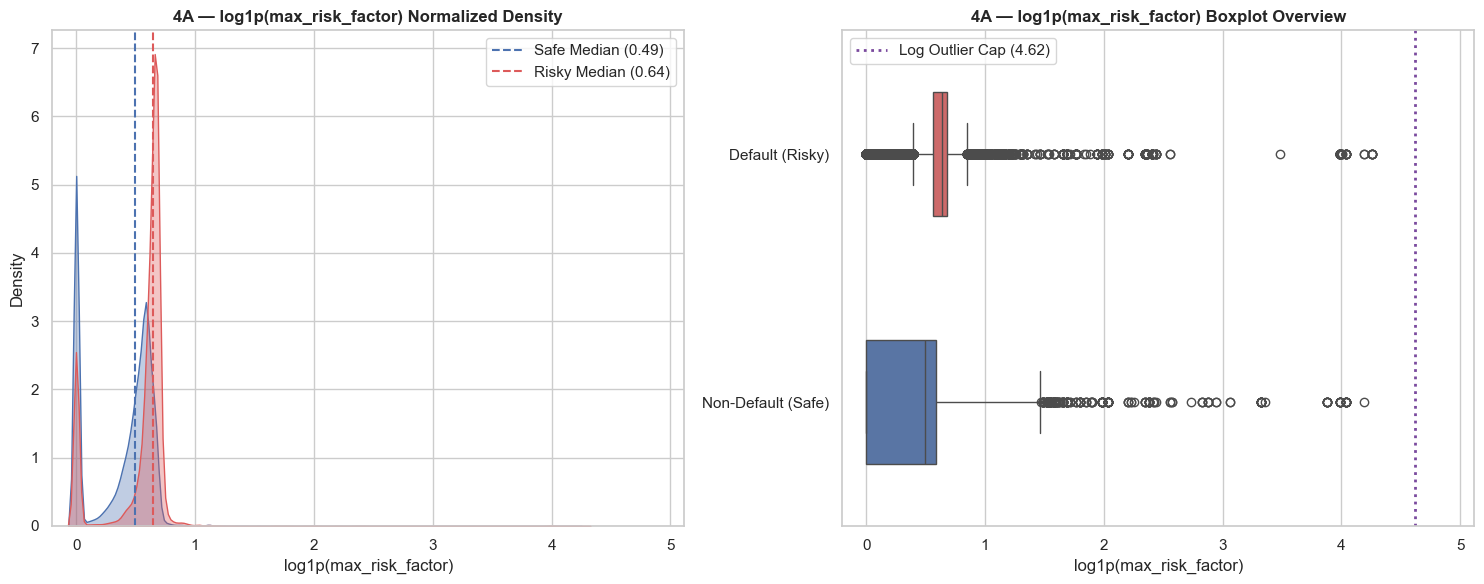

Risk cliff detected at bin: 0.8-0.9, PD jump: +23.15%
Risk cliff detected at bin: 0.9-1.0, PD jump: +29.33%


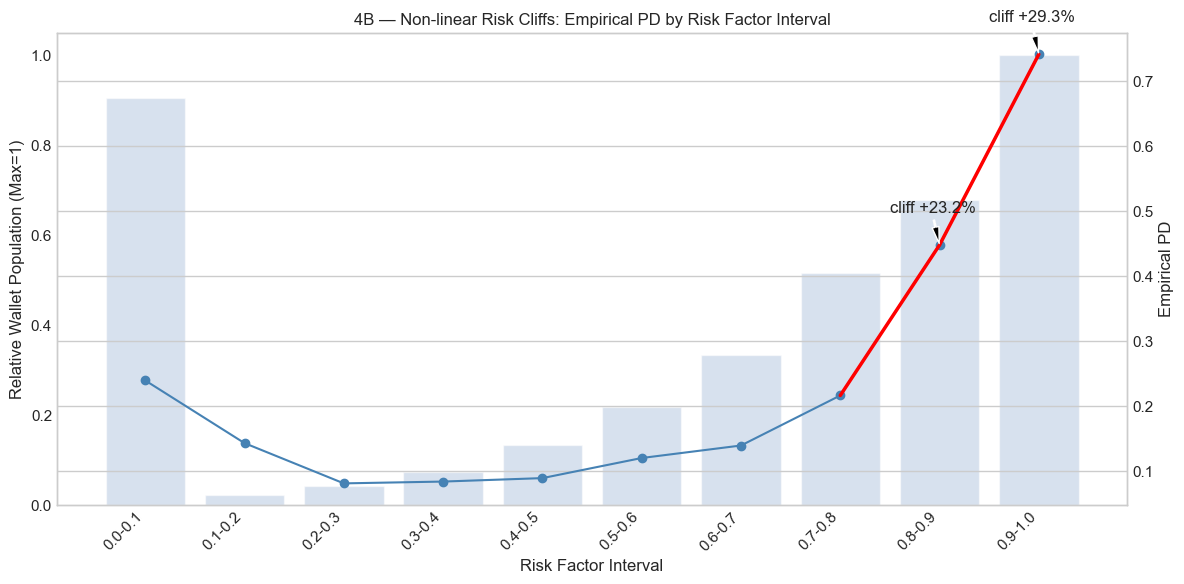

Liquidation Bucket Summary:
liq_bucket  wallet_count  default_rate
 0 (Never)        380892      0.313194
         1         23050      0.647722
         2         10064      0.727643
         3          5569      0.785599
        4+         23386      0.867143


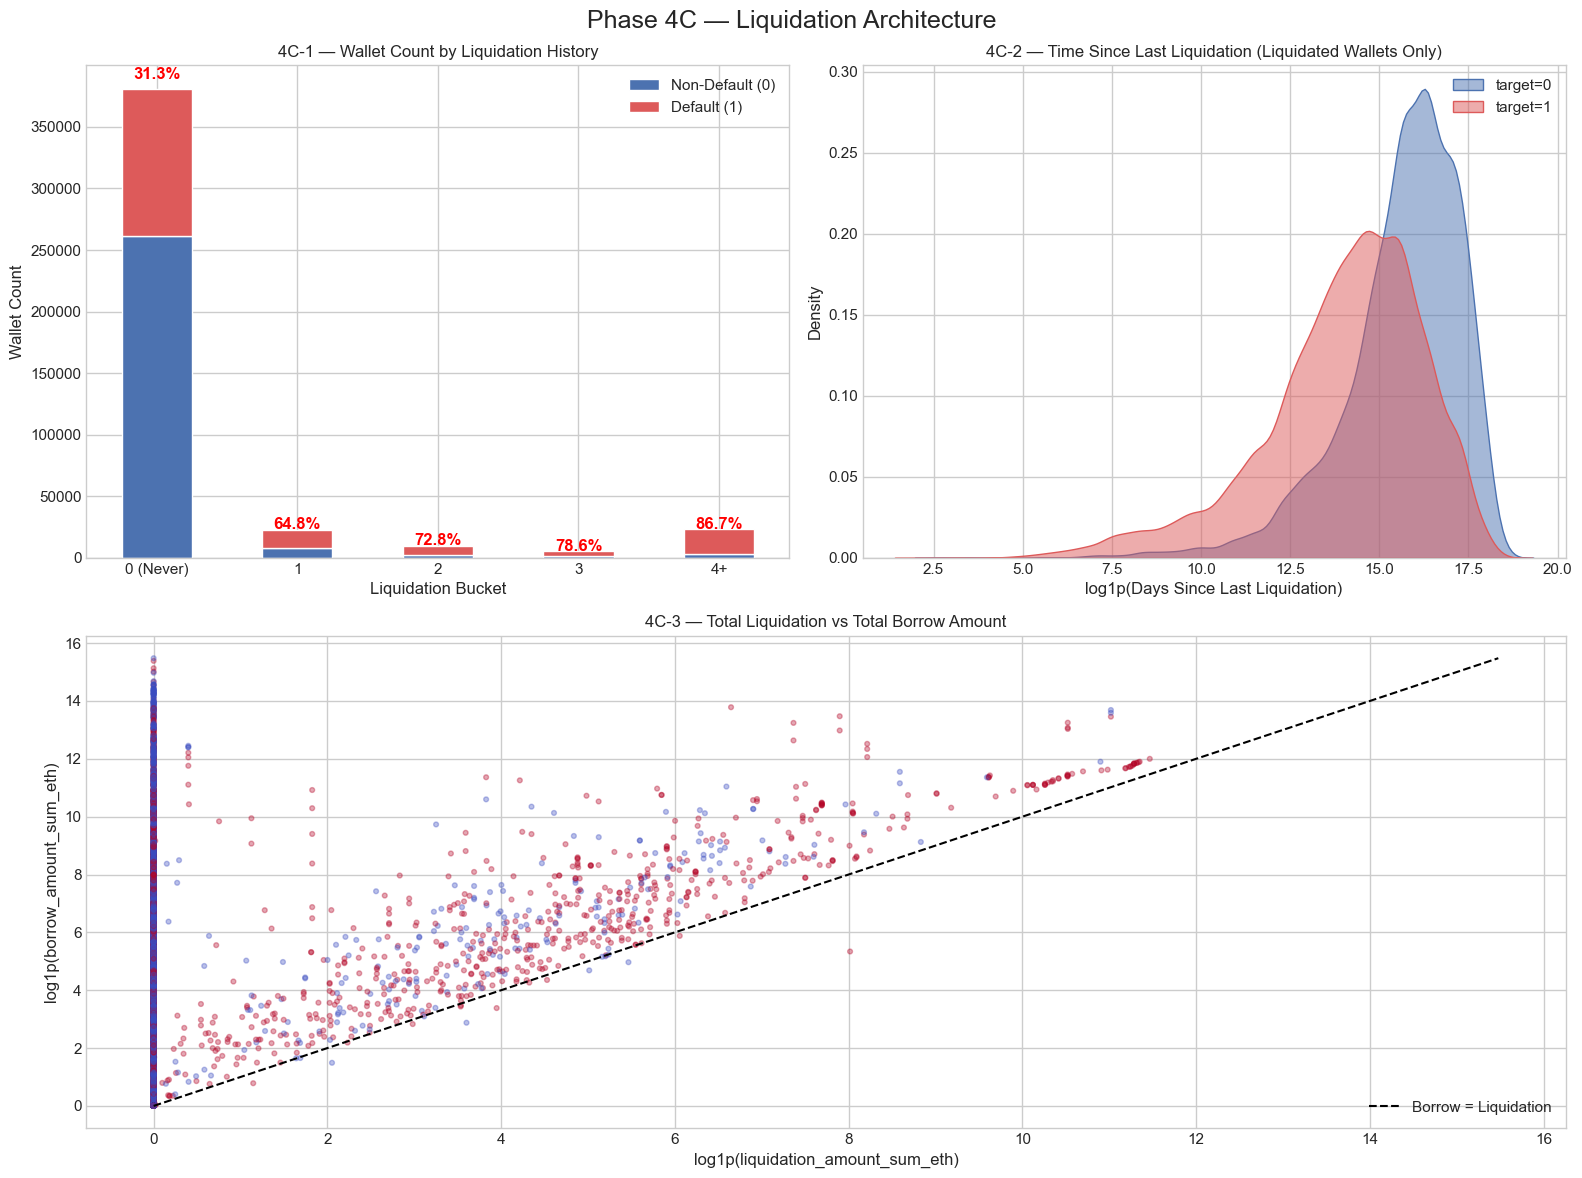

Borrow/Repay Discipline Summary:
   repay_bucket  wallet_count  default_rate
Severe Underpay        183554      0.354664
      High Risk         58623      0.465705
       Moderate         76383      0.430554
      Near Full         89532      0.359324
Overpay / Early         34869      0.250681


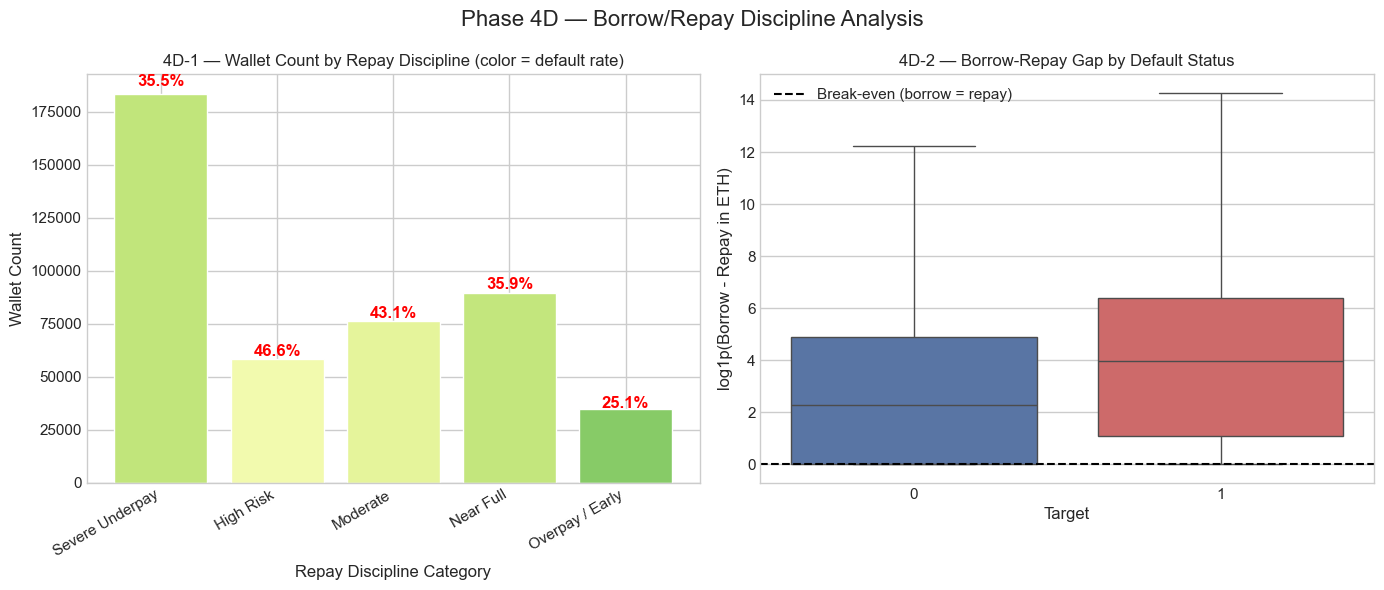

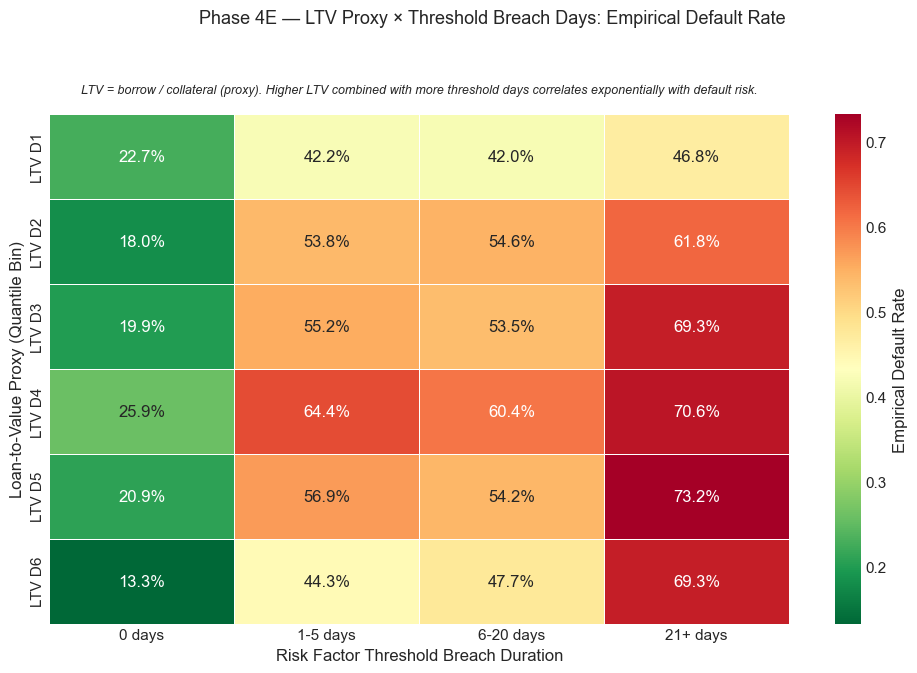

In [24]:
audit_max_risk_factor_tail(df)
detect_risk_cliffs(df)
plot_liquidation_deep_dive(df)
plot_borrow_repay_discipline(df)
plot_collateral_utilization_heatmap(df)

### Phase 5: Macro & Market Regime Context

### 5A: Market Regime Comparison

In [12]:
def plot_market_regime_comparison(df: pl.DataFrame,
                                   split_ts: int = 1_672_531_200,
                                   save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import matplotlib.ticker as mtick
        
        df_filtered = df.filter(pl.col("borrow_timestamp").is_not_null())
        
        df_filtered = df_filtered.with_columns([
            pl.when(pl.col("borrow_timestamp") < split_ts)
              .then(pl.lit("Bull Market"))
              .otherwise(pl.lit("Crypto Winter"))
              .alias("regime"),
            pl.from_epoch("borrow_timestamp", time_unit="s").dt.strftime("%Y-%m").alias("borrow_month")
        ])
        
        train_df = df_filtered.filter(pl.col("borrow_timestamp") < split_ts)
        test_df = df_filtered.filter(pl.col("borrow_timestamp") >= split_ts)
        
        train_size = len(train_df)
        train_pd = train_df["target"].mean() * 100 if train_size > 0 else 0.0
        
        test_size = len(test_df)
        test_pd = test_df["target"].mean() * 100 if test_size > 0 else 0.0
        
        regime_delta = test_pd - train_pd
        
        print(f"Train size: {train_size} | PD: {train_pd:.2f}% | Test size: {test_size} | PD: {test_pd:.2f}% | Regime PD delta: {regime_delta:+.2f}%")
        
        agg_df = df_filtered.group_by("borrow_month").agg([
            pl.len().alias("wallet_count"),
            pl.col("target").mean().alias("default_rate"),
            pl.col("regime").first().alias("regime")
        ]).sort("borrow_month").to_pandas()
        
        agg_df["rolling_3m_default_rate"] = agg_df["default_rate"].rolling(3, min_periods=1).mean()
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
        fig.suptitle("Phase 5A — Temporal Regime: Bull Market vs Crypto Winter", fontsize=16)
        
        ax1, ax2 = axes
        
        x_vals = np.arange(len(agg_df))
        months = agg_df["borrow_month"].values
        
        is_bull = agg_df["regime"] == "Bull Market"
        is_winter = agg_df["regime"] == "Crypto Winter"
        
        ax1.plot(x_vals, agg_df["wallet_count"], color="gray", alpha=0)
        
        ax1.fill_between(x_vals, 0, agg_df["wallet_count"], where=is_bull, color="green", alpha=0.5, label="Bull Market")
        ax1.fill_between(x_vals, 0, agg_df["wallet_count"], where=is_winter, color="red", alpha=0.4, label="Crypto Winter")
        
        winter_indices = np.where(is_winter)[0]
        split_idx = winter_indices[0] if len(winter_indices) > 0 else None
        
        if split_idx is not None:
            ax1.axvline(split_idx, color="black", linestyle="--")
            ax1.annotate("Train | Test", xy=(split_idx, ax1.get_ylim()[1]*0.9), 
                         xytext=(5, 0), textcoords="offset points", fontweight='bold')
                         
        ax1.set_ylabel("Monthly Borrow Volume")
        ax1.set_title("5A-1 — Monthly Wallet Borrow Activity")
        ax1.legend(loc="upper left")
        
        ax2.plot(x_vals, agg_df["rolling_3m_default_rate"], color="gray", alpha=0)
        
        if split_idx is not None:
            ax2.plot(x_vals[:split_idx+1], agg_df["rolling_3m_default_rate"][:split_idx+1], color="green", linewidth=2)
            ax2.plot(x_vals[split_idx:], agg_df["rolling_3m_default_rate"][split_idx:], color="red", linewidth=2)
            
            ax2.fill_between(x_vals[:split_idx+1], 0, agg_df["rolling_3m_default_rate"][:split_idx+1], color="green", alpha=0.25)
            ax2.fill_between(x_vals[split_idx:], 0, agg_df["rolling_3m_default_rate"][split_idx:], color="red", alpha=0.25)
            
            winter_df = agg_df.iloc[split_idx:]
            peak_idx = winter_df["rolling_3m_default_rate"].idxmax()
            if pd.notna(peak_idx):
                peak_val = winter_df.loc[peak_idx, "rolling_3m_default_rate"]
                ax2.annotate("Peak Default Spike", 
                             xy=(peak_idx, peak_val),
                             xytext=(peak_idx, peak_val*1.15),
                             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                             ha='center', fontweight='bold', color='darkred')
        else:
            ax2.plot(x_vals, agg_df["rolling_3m_default_rate"], color="green" if is_bull.all() else "red", linewidth=2)
            ax2.fill_between(x_vals, 0, agg_df["rolling_3m_default_rate"], color="green" if is_bull.all() else "red", alpha=0.25)
            
        ax2.set_ylabel("Rolling 3M Default Rate")
        ax2.set_title("5A-2 — Rolling Default Rate")
        ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
        
        ax2.set_xticks(x_vals)
        ax2.set_xticklabels(months, rotation=45, ha="right")
        
        # Show every N-th label to prevent crowding if there are many months
        n = max(1, len(x_vals) // 15)
        for i, label in enumerate(ax2.xaxis.get_ticklabels()):
            if i % n != 0:
                label.set_visible(False)
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase5a_market_regime_comparison.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

### 5B: Market Technical Indicator Correlation Analysis

In [13]:
def plot_market_indicator_correlations(df: pl.DataFrame,
                                        save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        from scipy.stats import spearmanr
        
        expected_cols = [
            "market_adx", "market_adxr", "market_apo", "market_aroonosc", "market_aroonup",
            "market_atr", "market_cci", "market_cmo", "market_correl", "market_dx",
            "market_fastk", "market_fastd", "market_ht_trendmode", "market_linearreg_slope",
            "market_macd_macdext", "market_macd_macdfix", "market_macd",
            "market_macdsignal_macdext", "market_macdsignal_macdfix", "market_macdsignal",
            "market_max_drawdown_365d", "market_natr", "market_plus_di", "market_plus_dm",
            "market_ppo", "market_rocp", "market_rocr"
        ]
        
        available_cols = [c for c in expected_cols if c in df.columns]
        missing_cols = set(expected_cols) - set(available_cols)
        if missing_cols:
            print(f"Warning: Missing columns {missing_cols}")
            
        if not available_cols:
            print("No market indicator columns found. Exiting.")
            return
            
        cols_to_select = available_cols + ["target"]
        df_pd = df.select(cols_to_select).to_pandas()
        
        df_pd = df_pd.fillna(df_pd.median())
        
        correlations = {}
        target_vals = df_pd["target"].values
        for col in available_cols:
            rho, _ = spearmanr(df_pd[col].values, target_vals)
            correlations[col] = rho if not np.isnan(rho) else 0.0
            
        sorted_corr_abs = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
        top_10 = [col for col, _ in sorted_corr_abs[:10]]
        
        print("Top 10 Market Indicators by Spearman ρ with target:")
        for col, rho in sorted_corr_abs[:10]:
            print(f"{col}: {rho:.4f}")
            
        top_10_corr = df_pd[top_10].corr(method="spearman")
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle("Phase 5B — Market Indicator Correlation Analysis", fontsize=16)
        
        ax1, ax2 = axes
        
        corr_series = pd.Series(correlations).sort_values()
        colors = ["#1a9988" if val > 0 else "#e07070" for val in corr_series.values]
        
        ax1.barh(corr_series.index, corr_series.values, color=colors)
        ax1.axvline(0, color="black", linestyle="--")
        ax1.set_xlabel("Spearman ρ with target")
        ax1.set_ylabel("Market Indicator")
        ax1.set_title("5B-1 — Market Indicators vs Default: Spearman ρ")
        
        mask = np.triu(np.ones_like(top_10_corr, dtype=bool))
        sns.heatmap(top_10_corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1, ax=ax2)
        ax2.set_title("5B-2 — Top 10 Market Indicators: Pairwise Spearman Correlation")
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase5b_market_indicator_correlations.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

Train size: 402754 | PD: 38.58% | Test size: 40207 | PD: 26.86% | Regime PD delta: -11.73%


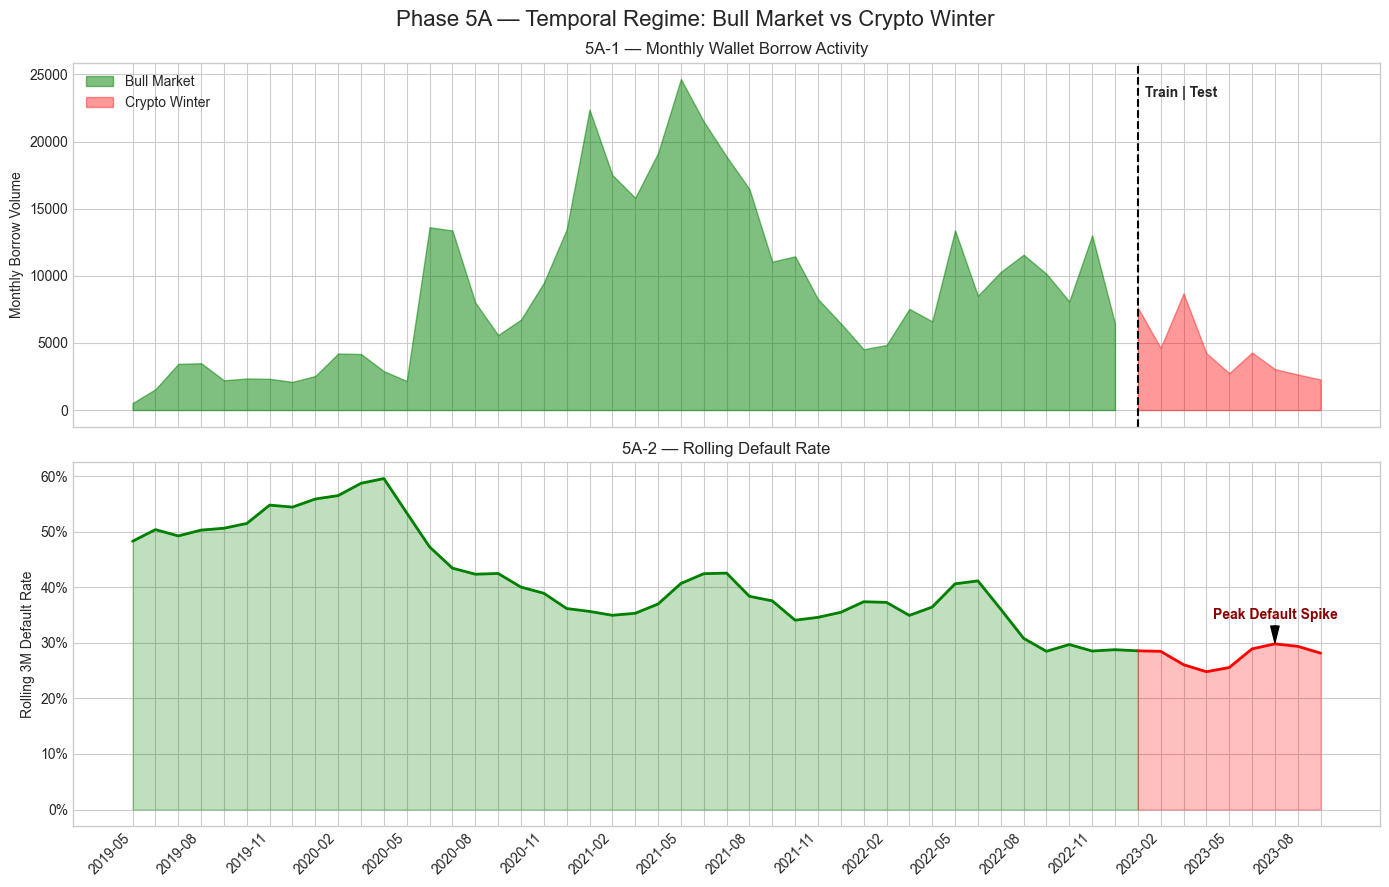

Top 10 Market Indicators by Spearman ρ with target:
market_max_drawdown_365d: 0.0512
market_atr: -0.0326
market_adx: 0.0185
market_aroonosc: 0.0184
market_adxr: 0.0157
market_plus_dm: -0.0151
market_correl: 0.0131
market_fastd: 0.0116
market_fastk: 0.0114
market_cmo: 0.0103


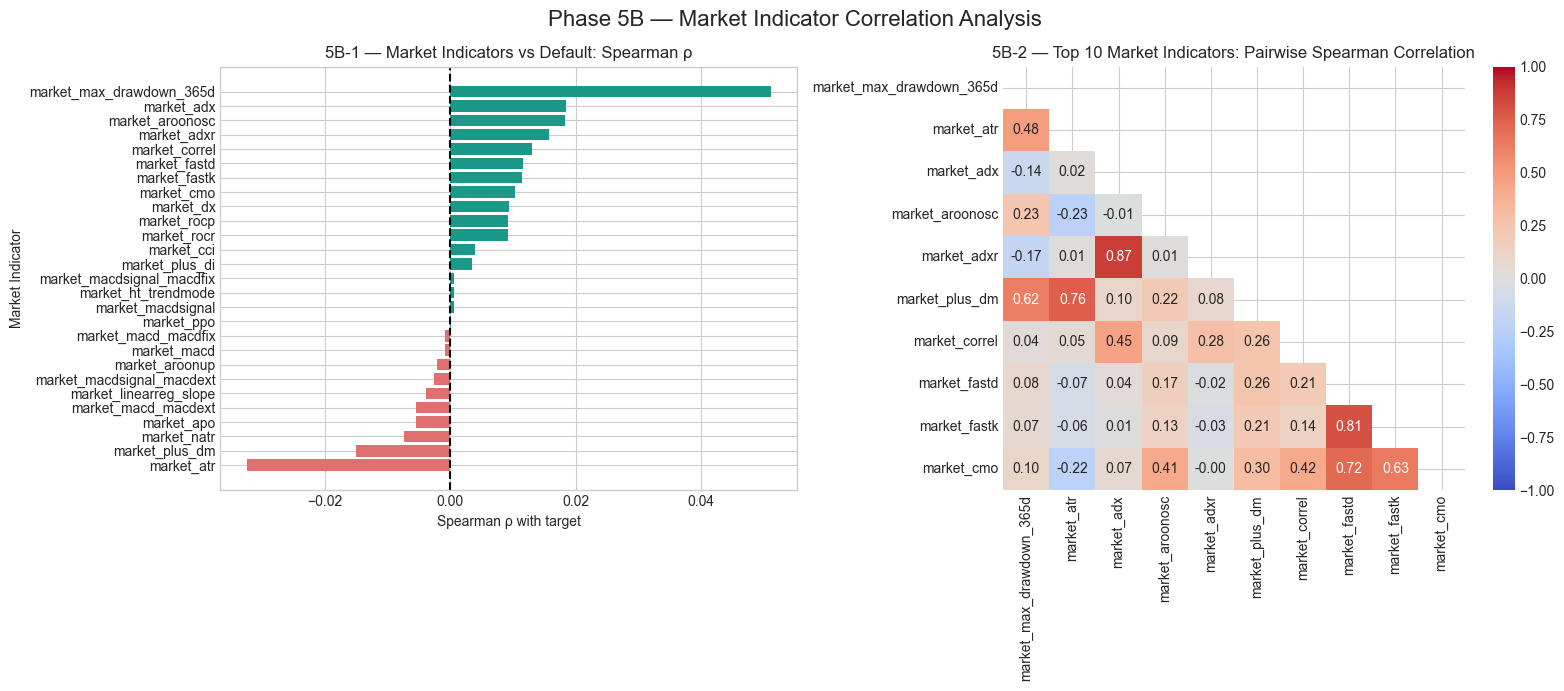

### 5C: Drawdown & Momentum Regime Space Analysis

In [ ]:
def plot_drawdown_momentum_regime(df: pl.DataFrame,
                                   sample_n: int = 6000,
                                   save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        expected_cols = ["market_max_drawdown_365d", "market_macd", "market_cci",
                         "market_atr", "market_linearreg_slope"]
        
        missing_cols = [c for c in expected_cols if c not in df.columns]
        if missing_cols:
            print(f"Warning: Missing columns {missing_cols}. Plotting may fail for some panels.")
            
        available_cols = [c for c in expected_cols if c in df.columns]
        
        for c in available_cols:
            median_val = df.select(pl.col(c).median()).item()
            if median_val is not None:
                df = df.with_columns(pl.col(c).fill_null(median_val))
                
        if len(df) > sample_n:
            df_sample = df.sample(sample_n, seed=42)
        else:
            df_sample = df
            
        df_pd = df_sample.select(available_cols + ["target"]).to_pandas()
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(2, 2, figsize=(14, 11))
        fig.suptitle("Phase 5C — Drawdown & Momentum Market Regimes", fontsize=16)
        
        ax1, ax2 = axes[0]
        ax3, ax4 = axes[1]
        
        if "market_max_drawdown_365d" in df_pd.columns:
            sns.kdeplot(data=df_pd[df_pd["target"] == 0], x="market_max_drawdown_365d", fill=True, alpha=0.45, color="#1a9641", ax=ax1, label="Target 0")
            sns.kdeplot(data=df_pd[df_pd["target"] == 1], x="market_max_drawdown_365d", fill=True, alpha=0.45, color="#d7191c", ax=ax1, label="Target 1")
            ax1.set_title("5C-1 — 365-Day Max Drawdown by Default Status")
            ax1.legend()
            
        if "market_macd" in df_pd.columns and "market_cci" in df_pd.columns:
            ax2.scatter(df_pd["market_macd"], df_pd["market_cci"], c=df_pd["target"], cmap="coolwarm", alpha=0.35, s=10)
            ax2.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
            ax2.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
            
            xlim = ax2.get_xlim()
            ylim = ax2.get_ylim()
            
            ax2.text(xlim[1]*0.5, ylim[1]*0.5, "Bullish + Overbought", style="italic", ha="center", va="center", alpha=0.7)
            ax2.text(xlim[0]*0.5, ylim[1]*0.5, "Bearish + Overbought", style="italic", ha="center", va="center", alpha=0.7)
            ax2.text(xlim[0]*0.5, ylim[0]*0.5, "Bearish + Oversold", style="italic", ha="center", va="center", alpha=0.7)
            ax2.text(xlim[1]*0.5, ylim[0]*0.5, "Bullish + Oversold", style="italic", ha="center", va="center", alpha=0.7)
            
            ax2.set_xlabel("market_macd")
            ax2.set_ylabel("market_cci")
            ax2.set_title("5C-2 — MACD × CCI Momentum Space")
            
        if "market_atr" in df_pd.columns:
            sns.boxplot(data=df_pd, x="target", y="market_atr", hue="target", palette={0:"#4C72B0", 1:"#DD5A5A"}, ax=ax3, showfliers=False, orient="v", legend=False)
            ax3.set_title("5C-3 — Market Volatility (ATR) by Default Status")
            ax3.set_xlabel("Target")
            
        if "market_linearreg_slope" in df_pd.columns:
            sns.violinplot(data=df_pd, x="target", y="market_linearreg_slope", hue="target", palette={0:"#4C72B0", 1:"#DD5A5A"}, inner="quartile", ax=ax4, legend=False)
            ax4.axhline(y=0, color="black", linestyle="--", label="Flat Trend")
            ax4.set_title("5C-4 — Price Trend Slope by Default Status")
            ax4.set_xlabel("Target")
            ax4.legend()
            
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase5c_drawdown_momentum_regime.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

Train size: 402754 | PD: 38.58% | Test size: 40207 | PD: 26.86% | Regime PD delta: -11.73%


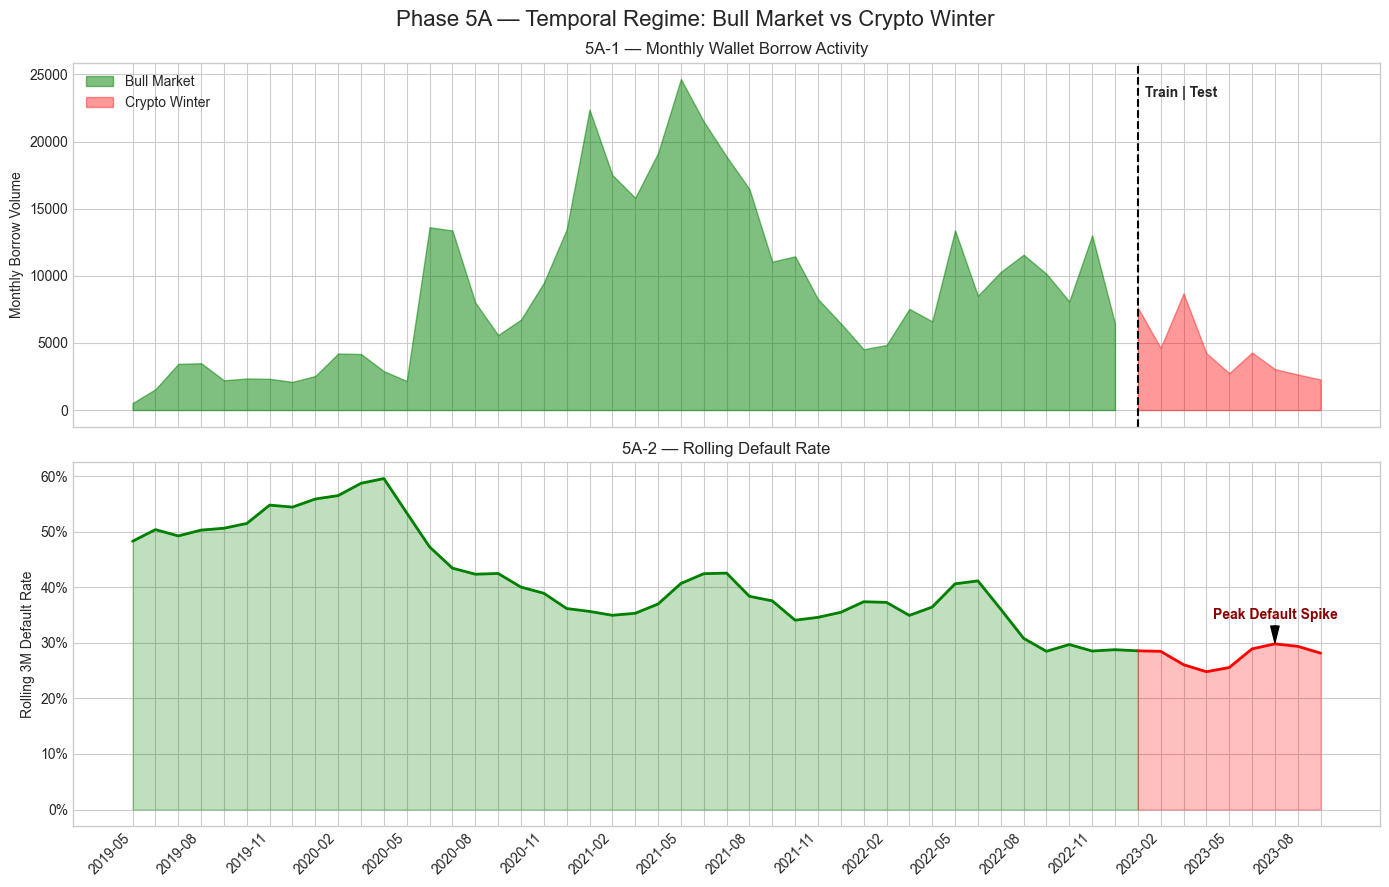

Top 10 Market Indicators by Spearman ρ with target:
market_max_drawdown_365d: 0.0512
market_atr: -0.0326
market_adx: 0.0185
market_aroonosc: 0.0184
market_adxr: 0.0157
market_plus_dm: -0.0151
market_correl: 0.0131
market_fastd: 0.0116
market_fastk: 0.0114
market_cmo: 0.0103


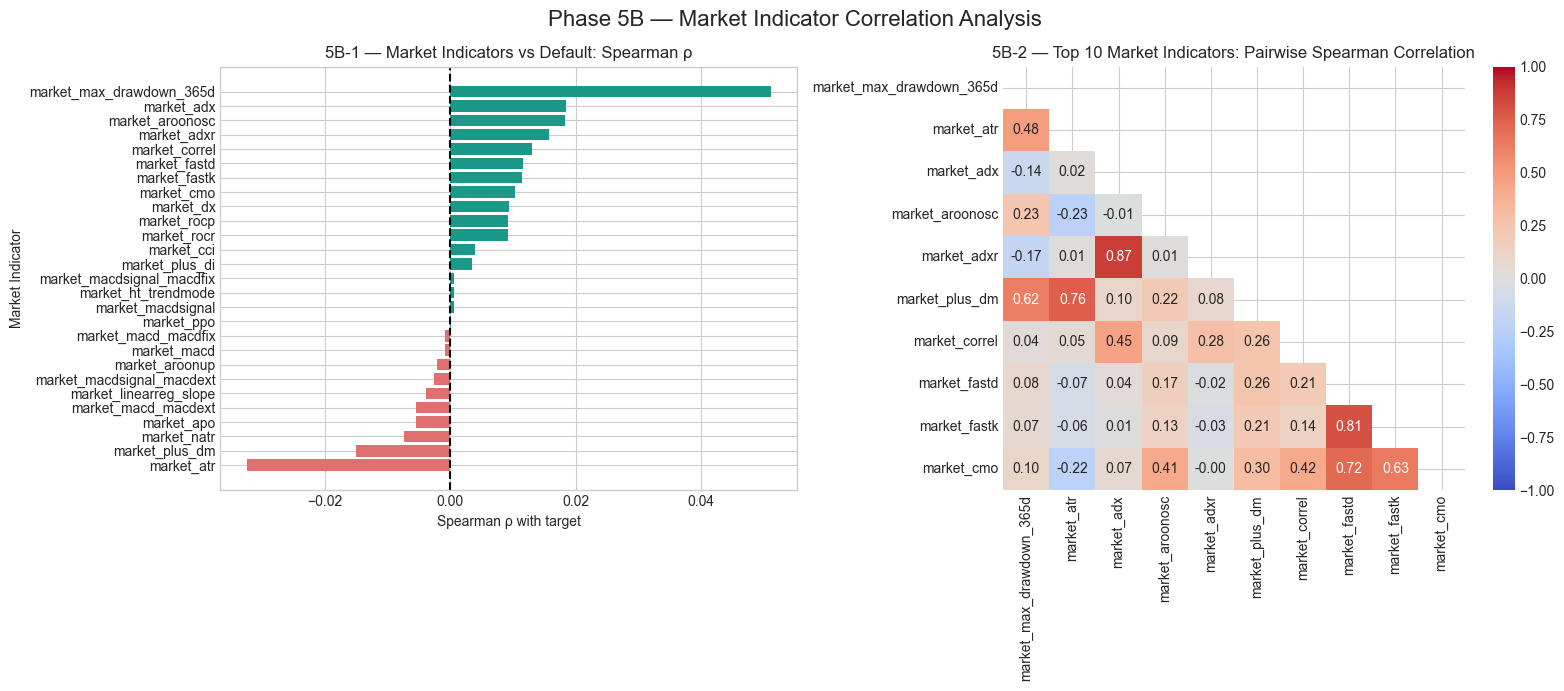

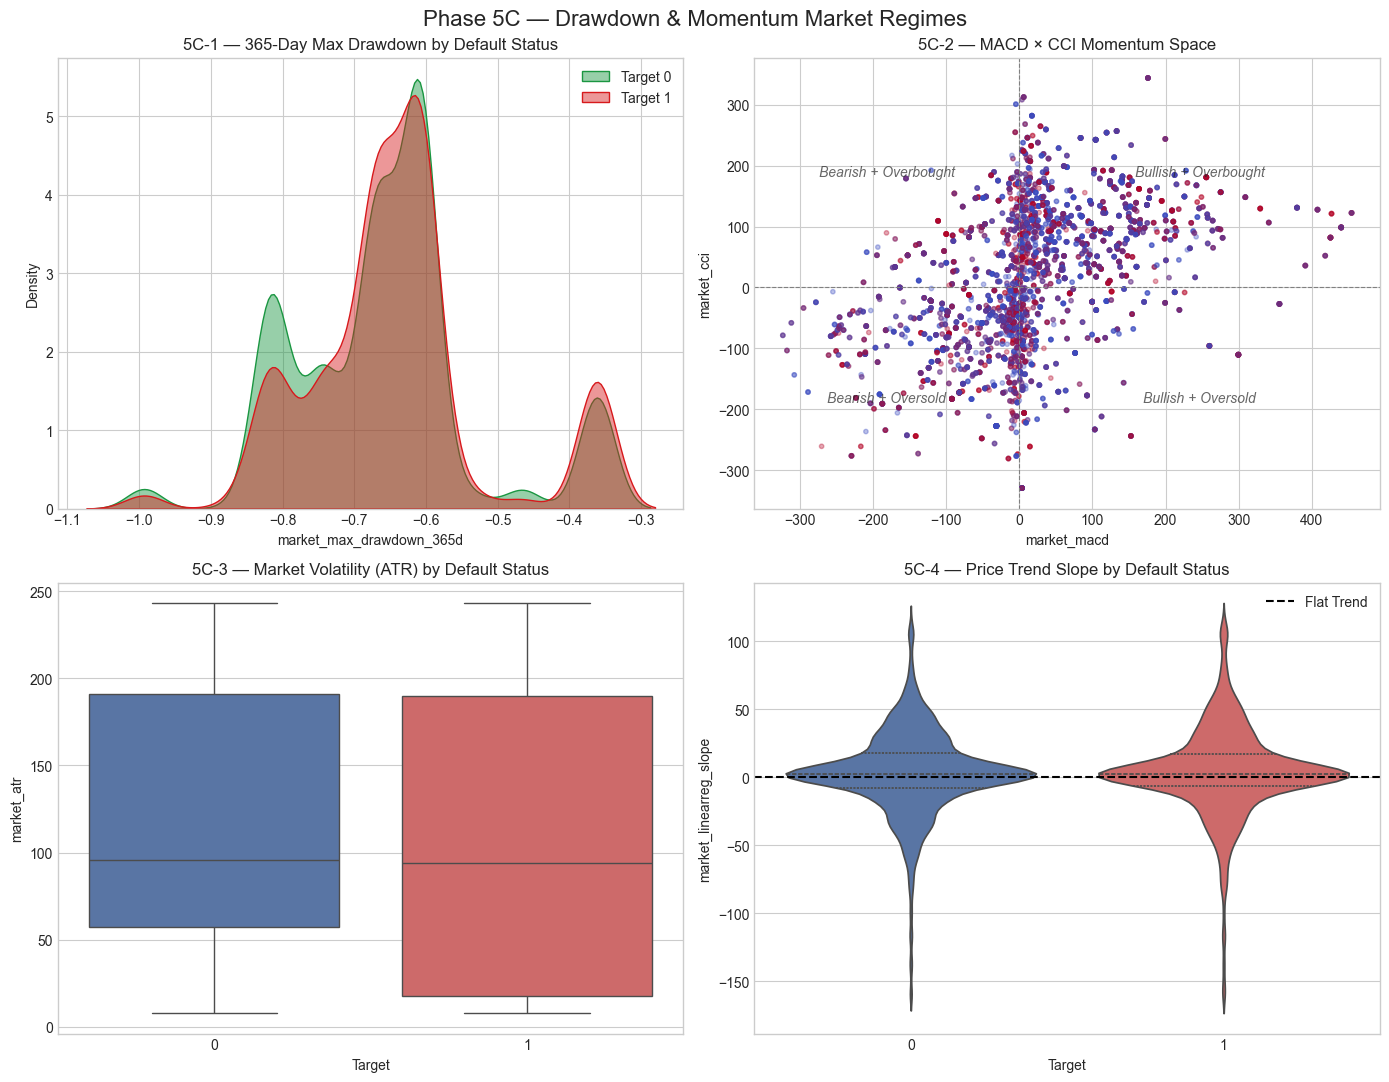

In [18]:
plot_market_regime_comparison(df)
plot_market_indicator_correlations(df)
plot_drawdown_momentum_regime(df)

## Phase 6: Global Feature Importance & Synthesis

### 6A: MI and KS Distance Ranking

In [19]:
def compute_mi_ks_ranking(df: pl.DataFrame,
                           noise_mi_threshold: float = 0.001,
                           save_dir: str = "reports/figures") -> pl.DataFrame:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import matplotlib.cm as cm
        import matplotlib.colors as mcolors
        from sklearn.feature_selection import mutual_info_classif
        from scipy.stats import ks_2samp
        
        structural = ["wallet_address", "borrow_block_number", "target",
                      "borrow_timestamp", "risk_bucket", "Archetype",
                      "first_tx_timestamp", "last_tx_timestamp",
                      "risky_first_tx_timestamp", "risky_last_tx_timestamp"]
                      
        numeric_cols = []
        for col in df.columns:
            if col not in structural:
                dtype = df.schema[col]
                if dtype in [pl.Float64, pl.Float32, pl.Int64, pl.Int32]:
                    numeric_cols.append(col)
                    
        if not numeric_cols:
            print("No numeric columns found.")
            return pl.DataFrame()
            
        cols_to_select = numeric_cols + ["target"]
        df_pd = df.select(cols_to_select).to_pandas()
        
        X = df_pd[numeric_cols].fillna(0)
        y = df_pd["target"]
        
        X.replace([np.inf, -np.inf], 0, inplace=True)
        
        mi_scores = mutual_info_classif(X, y, random_state=42)
        
        ks_distances = []
        target_0_mask = y == 0
        target_1_mask = y == 1
        
        for col in numeric_cols:
            good_vals = X.loc[target_0_mask, col].values
            bad_vals = X.loc[target_1_mask, col].values
            
            if len(good_vals) == 0 or len(bad_vals) == 0:
                ks_distances.append(0.0)
            else:
                stat = ks_2samp(good_vals, bad_vals).statistic
                ks_distances.append(stat)
                
        eval_df_pd = pd.DataFrame({
            "Feature_Name": numeric_cols,
            "MI_Score": mi_scores,
            "KS_Distance": ks_distances
        }).sort_values("MI_Score", ascending=False)
        
        eval_df = pl.DataFrame(eval_df_pd)
        
        noise_count = (eval_df_pd["MI_Score"] <= noise_mi_threshold).sum()
        print(f"Noise candidates (MI_Score <= {noise_mi_threshold}): {noise_count}")
        print("Top 15 features by MI_Score:")
        print(eval_df_pd.head(15).to_string(index=False))
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 9))
        
        top20_mi = eval_df_pd.head(20).copy()
        top20_mi = top20_mi.sort_values("MI_Score", ascending=True)
        
        norm1 = mcolors.Normalize(vmin=top20_mi["KS_Distance"].min(), vmax=top20_mi["KS_Distance"].max())
        cmap1 = cm.viridis
        colors1 = [cmap1(norm1(val)) for val in top20_mi["KS_Distance"]]
        
        bars1 = ax1.barh(top20_mi["Feature_Name"], top20_mi["MI_Score"], color=colors1)
        ax1.set_title("6A-1 — Top 20 Features: MI Score")
        ax1.set_xlabel("MI Score")
        
        sm1 = plt.cm.ScalarMappable(cmap=cmap1, norm=norm1)
        sm1.set_array([])
        cbar1 = fig.colorbar(sm1, ax=ax1, orientation='vertical')
        cbar1.set_label("KS Distance")
        
        top20_ks = eval_df_pd.sort_values("KS_Distance", ascending=False).head(20).copy()
        top20_ks = top20_ks.sort_values("KS_Distance", ascending=True)
        
        norm2 = mcolors.Normalize(vmin=top20_ks["MI_Score"].min(), vmax=top20_ks["MI_Score"].max())
        cmap2 = cm.plasma
        colors2 = [cmap2(norm2(val)) for val in top20_ks["MI_Score"]]
        
        bars2 = ax2.barh(top20_ks["Feature_Name"], top20_ks["KS_Distance"], color=colors2)
        ax2.set_title("6A-2 — Top 20 Features: KS Distance")
        ax2.set_xlabel("KS Distance")
        
        sm2 = plt.cm.ScalarMappable(cmap=cmap2, norm=norm2)
        sm2.set_array([])
        cbar2 = fig.colorbar(sm2, ax=ax2, orientation='vertical')
        cbar2.set_label("MI Score")
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase6a_mi_ks_ranking.png", dpi=150)
        plt.show()
        
        return eval_df
    except Exception as e:
        print(f"Error in compute_mi_ks_ranking: {e}")
        raise e

Noise candidates (MI_Score <= 0.001): 0
Top 15 features by MI_Score:
                           Feature_Name  MI_Score  KS_Distance
                           max_eth_ever  0.342559     0.046527
                           min_eth_ever  0.275108     0.110137
                withdraw_amount_sum_eth  0.226625     0.081577
                   repay_amount_avg_eth  0.210135     0.084799
                   repay_amount_sum_eth  0.205684     0.085296
                            risk_factor  0.174597     0.465106
                      total_balance_eth  0.162789     0.123665
                        max_risk_factor  0.162388     0.465092
          risky_sum_outgoing_amount_eth  0.138962     0.041260
                 deposit_amount_sum_eth  0.131767     0.069429
                        avg_risk_factor  0.129040     0.407450
risk_factor_above_threshold_daily_count  0.119505     0.449688
             time_since_last_liquidated  0.111873     0.227901
     risky_first_last_tx_timestamp_diff  0.104954

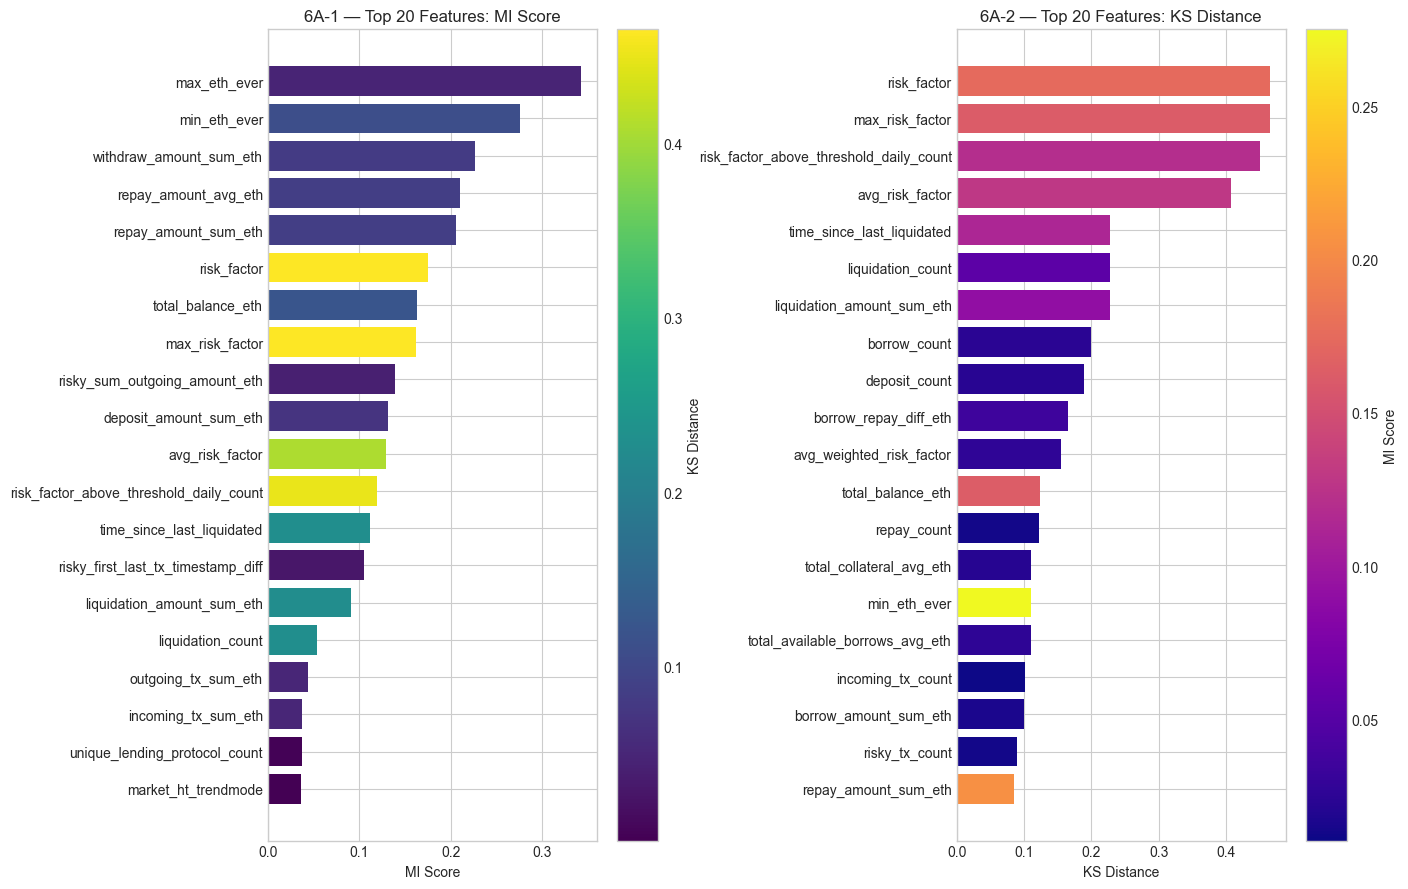

In [20]:
eval_df = compute_mi_ks_ranking(df)

### 6B: DeFi Wallet Archetype Segmentation and Terminal Quality Gate

Medians -> Collateral: 135.7947335041385, Gas: 0.010690976303098279, Age: 21205141.0, TX: 158.0, Risk: 0.44156770355591635
Archetype Summary:
          Archetype  wallet_volume  empirical_pd  median_collateral  median_risk  liq_rate
             Retail         253454      0.350442         117.358880     0.423516  0.062185
              Whale          79032      0.333232         915.969103     0.458969  0.063354
            Dormant          43595      0.253882           6.833270     0.000397  0.030141
         DeFi Degen          36060      0.404493          33.192438     0.467490  0.254215
Liquidation Veteran          30820      0.823783         373.149701     0.762640  1.000000


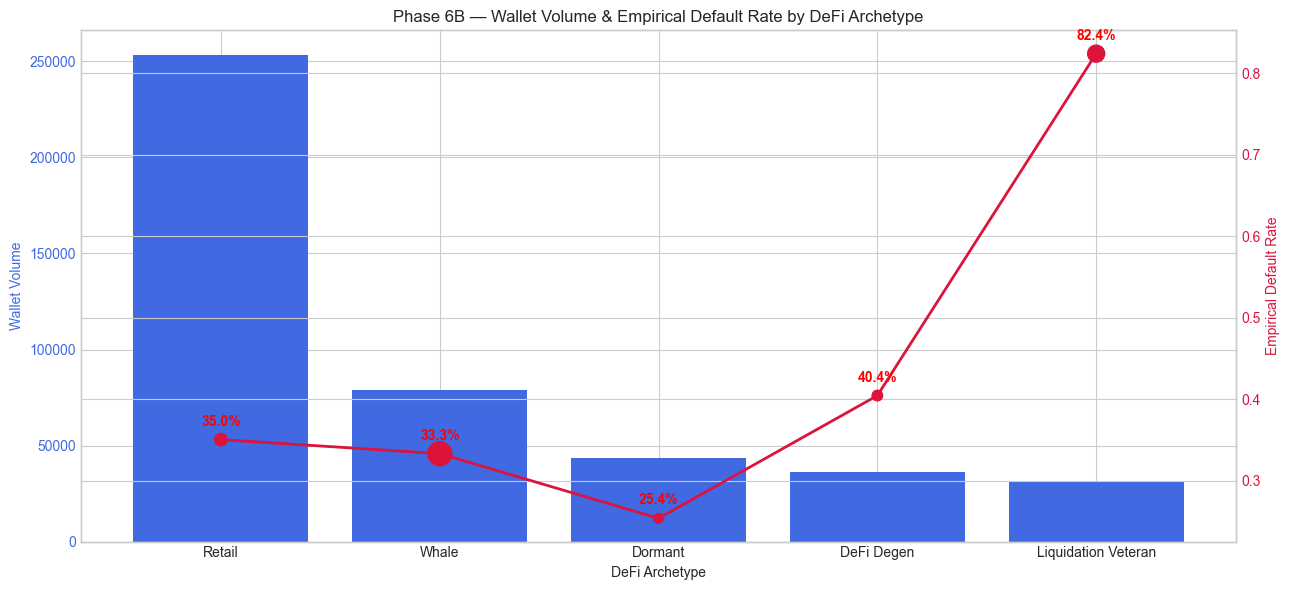

Terminal Quality Gate: PASSED. Dataset cleared for downstream modeling.
Final shape: (442961, 79)


In [21]:
def segment_defi_archetypes(df: pl.DataFrame,
                             save_dir: str = "reports/figures") -> pl.DataFrame:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    med_collateral = df.select(pl.col("total_collateral_eth").median()).item()
    med_gas = df.select(pl.col("avg_gas_paid_per_tx_eth").median()).item()
    med_age = df.select(pl.col("wallet_age").median()).item()
    med_tx = df.select(pl.col("incoming_tx_count").median()).item()
    med_risk = df.select(pl.col("avg_risk_factor").median()).item()
    
    print(f"Medians -> Collateral: {med_collateral}, Gas: {med_gas}, Age: {med_age}, TX: {med_tx}, Risk: {med_risk}")
    
    df = df.with_columns(
        pl.when((pl.col("total_collateral_eth") > med_collateral) & (pl.col("incoming_tx_count") <= med_tx)).then(pl.lit("Whale"))
          .when((pl.col("total_collateral_eth") <= med_collateral) & (pl.col("avg_gas_paid_per_tx_eth") > med_gas) & (pl.col("incoming_tx_count") > med_tx)).then(pl.lit("DeFi Degen"))
          .when(pl.col("liquidation_count") >= 2).then(pl.lit("Liquidation Veteran"))
          .when((pl.col("wallet_age") > med_age) & (pl.col("incoming_tx_count") <= med_tx)).then(pl.lit("Dormant"))
          .otherwise(pl.lit("Retail"))
          .alias("Archetype")
    )
    
    agg_df = df.group_by("Archetype").agg([
        pl.len().alias("wallet_volume"),
        pl.col("target").mean().alias("empirical_pd"),
        pl.col("total_collateral_eth").median().alias("median_collateral"),
        pl.col("avg_risk_factor").median().alias("median_risk"),
        (pl.col("liquidation_count") > 0).cast(pl.Int8).mean().alias("liq_rate")
    ]).sort("wallet_volume", descending=True)
    
    agg_pd = agg_df.to_pandas()
    print("Archetype Summary:")
    print(agg_pd.to_string(index=False))
    
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, ax1 = plt.subplots(figsize=(13, 6))
        
        x_pos = np.arange(len(agg_pd))
        
        ax1.bar(x_pos, agg_pd["wallet_volume"], color="royalblue")
        ax1.set_ylabel("Wallet Volume", color="royalblue")
        ax1.set_xlabel("DeFi Archetype")
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(agg_pd["Archetype"])
        ax1.tick_params(axis='y', labelcolor="royalblue")
        
        ax2 = ax1.twinx()
        
        s_min = 50
        s_max = 300
        collateral_vals = agg_pd["median_collateral"]
        if collateral_vals.max() > collateral_vals.min():
            norm_sizes = s_min + (collateral_vals - collateral_vals.min()) / (collateral_vals.max() - collateral_vals.min()) * (s_max - s_min)
        else:
            norm_sizes = np.full(len(collateral_vals), (s_min + s_max) / 2)
            
        ax2.plot(x_pos, agg_pd["empirical_pd"], color="crimson", linewidth=2, zorder=1)
        ax2.scatter(x_pos, agg_pd["empirical_pd"], s=norm_sizes, color="crimson", zorder=2)
        
        for i, pd_val in enumerate(agg_pd["empirical_pd"]):
            ax2.annotate(f"{pd_val*100:.1f}%", xy=(x_pos[i], pd_val),
                         xytext=(0, 10), textcoords="offset points", ha='center',
                         color="red", fontweight="bold")
                         
        ax2.set_ylabel("Empirical Default Rate", color="crimson")
        ax2.tick_params(axis='y', labelcolor="crimson")
        
        plt.title("Phase 6B — Wallet Volume & Empirical Default Rate by DeFi Archetype")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase6b_defi_archetype_segmentation.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"Plotting error: {e}")
        
    total_nulls = df.select(pl.all().null_count()).sum_horizontal().item()
    if total_nulls != 0:
        raise AssertionError(f"Data integrity failure: {total_nulls} nulls found.")
        
    print("Terminal Quality Gate: PASSED. Dataset cleared for downstream modeling.")
    print(f"Final shape: {df.shape}")
    
    return df

df = segment_defi_archetypes(df)

### 6C: Final Feature Shortlist, Composite Scoring, and EDA Summary Dashboard

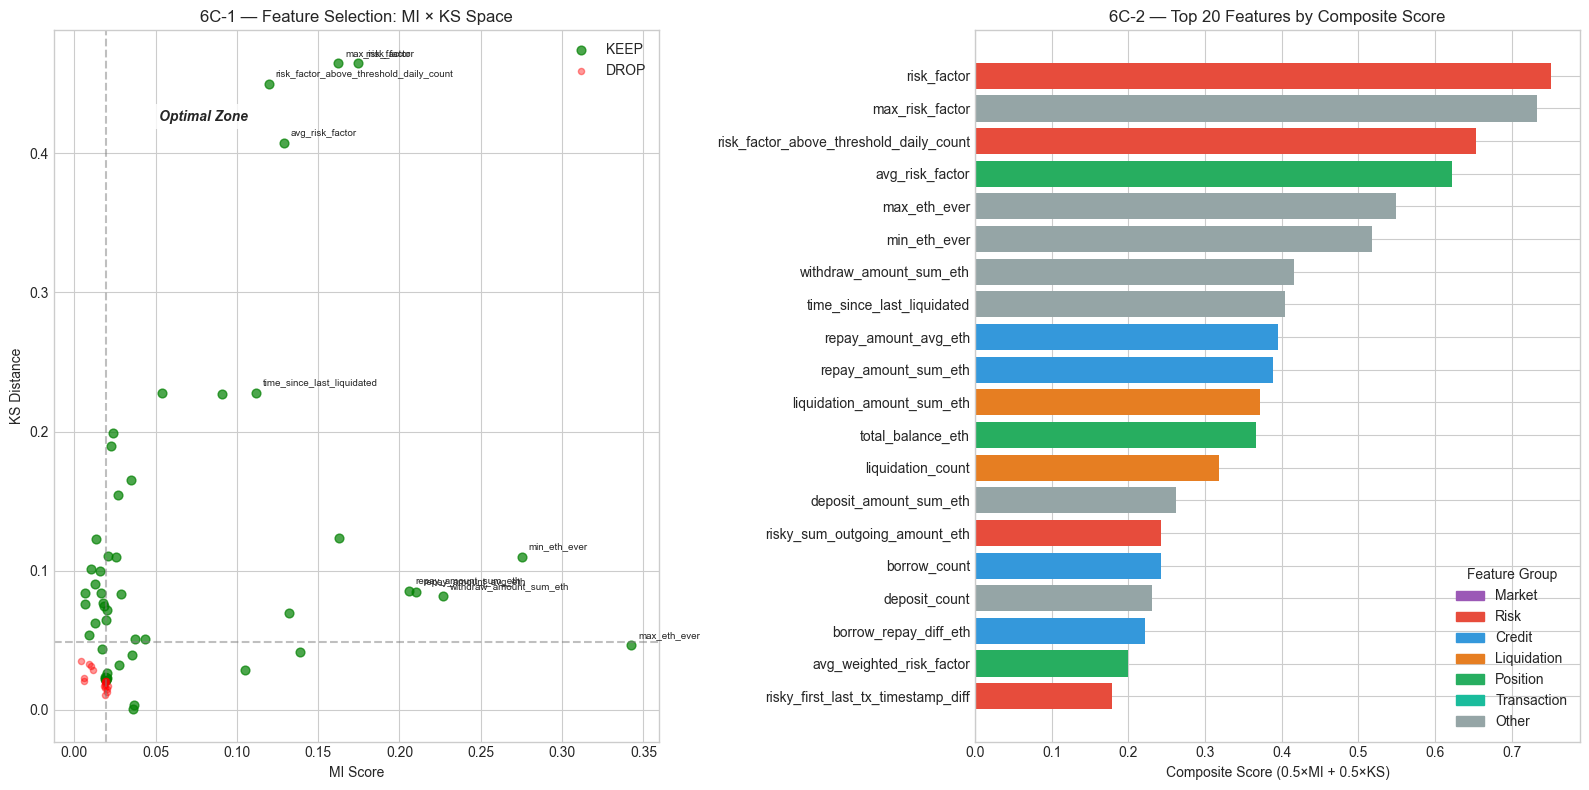

Shortlist exported: reports/model_feature_shortlist.csv
EDA FUNNEL COMPLETE
Total features evaluated: 70
Features KEPT for modeling: 52 (74%)
Features DROPPED (noise/redundant): 18
Top 5 features by composite score: ['risk_factor', 'max_risk_factor', 'risk_factor_above_threshold_daily_count', 'avg_risk_factor', 'max_eth_ever']
Figures saved to: reports/figures/
Model input shortlist: reports/model_feature_shortlist.csv
Pipeline status: CLEARED — ready for Notebook 2.0 preprocessing


In [22]:
def build_feature_shortlist(eval_df: pl.DataFrame,
                             top_n: int = 52,
                             save_dir: str = "reports/figures") -> pl.DataFrame:
    try:
        import os
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        import matplotlib.patches as mpatches
        try:
            from adjustText import adjust_text
            has_adjust_text = True
        except ImportError:
            has_adjust_text = False
            
        mi_min = eval_df.select(pl.col("MI_Score").min()).item()
        mi_max = eval_df.select(pl.col("MI_Score").max()).item()
        ks_min = eval_df.select(pl.col("KS_Distance").min()).item()
        ks_max = eval_df.select(pl.col("KS_Distance").max()).item()
        
        if mi_min is None: mi_min = 0
        if mi_max is None: mi_max = 0
        if ks_min is None: ks_min = 0
        if ks_max is None: ks_max = 0
        
        df = eval_df.with_columns([
            ((pl.col("MI_Score") - mi_min) / (mi_max - mi_min + 1e-9)).alias("norm_mi"),
            ((pl.col("KS_Distance") - ks_min) / (ks_max - ks_min + 1e-9)).alias("norm_ks")
        ])
        
        df = df.with_columns(
            (0.5 * pl.col("norm_mi") + 0.5 * pl.col("norm_ks")).alias("composite_score")
        ).sort("composite_score", descending=True)
        
        if len(df) > 0:
            df = df.with_columns(
                pl.when(pl.arange(0, pl.len()) < top_n).then(pl.lit("KEEP")).otherwise(pl.lit("DROP")).alias("status")
            )
        else:
            df = df.with_columns(pl.lit("DROP").alias("status"))
            
        df = df.with_columns(
            pl.when(pl.col("Feature_Name").str.starts_with("market_")).then(pl.lit("Market"))
              .when(pl.col("Feature_Name").str.starts_with("risk")).then(pl.lit("Risk"))
              .when(pl.col("Feature_Name").str.starts_with("borrow") | pl.col("Feature_Name").str.starts_with("repay")).then(pl.lit("Credit"))
              .when(pl.col("Feature_Name").str.starts_with("liquidat")).then(pl.lit("Liquidation"))
              .when(pl.col("Feature_Name").str.starts_with("total_") | pl.col("Feature_Name").str.starts_with("avg_")).then(pl.lit("Position"))
              .when(pl.col("Feature_Name").str.starts_with("incoming") | pl.col("Feature_Name").str.starts_with("outgoing") | pl.col("Feature_Name").str.starts_with("tx")).then(pl.lit("Transaction"))
              .otherwise(pl.lit("Other"))
              .alias("feature_group")
        )
        
        df_pd = df.to_pandas()
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        keep_mask = df_pd["status"] == "KEEP"
        drop_mask = df_pd["status"] == "DROP"
        
        ax1.scatter(df_pd.loc[keep_mask, "MI_Score"], df_pd.loc[keep_mask, "KS_Distance"], 
                    color="green", alpha=0.7, s=40, label="KEEP")
        ax1.scatter(df_pd.loc[drop_mask, "MI_Score"], df_pd.loc[drop_mask, "KS_Distance"], 
                    color="red", alpha=0.4, s=20, label="DROP")
                    
        mi_med = df_pd["MI_Score"].median()
        ks_med = df_pd["KS_Distance"].median()
        
        ax1.axvline(mi_med, color="gray", linestyle="--", alpha=0.5)
        ax1.axhline(ks_med, color="gray", linestyle="--", alpha=0.5)
        
        top_10 = df_pd[keep_mask].head(10)
        texts = []
        for _, row in top_10.iterrows():
            if has_adjust_text:
                texts.append(ax1.text(row["MI_Score"], row["KS_Distance"], row["Feature_Name"], fontsize=7))
            else:
                ax1.annotate(row["Feature_Name"], xy=(row["MI_Score"], row["KS_Distance"]), 
                             xytext=(5, 5), textcoords="offset points", fontsize=7)
                             
        if has_adjust_text and texts:
            adjust_text(texts, ax=ax1, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
            
        ax1.text(mi_med + (df_pd["MI_Score"].max() - mi_med)*0.1 if pd.notna(mi_med) else 0, 
                 ks_med + (df_pd["KS_Distance"].max() - ks_med)*0.9 if pd.notna(ks_med) else 0, 
                 "Optimal Zone", fontsize=10, style="italic", fontweight="bold", 
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
                 
        ax1.set_xlabel("MI Score")
        ax1.set_ylabel("KS Distance")
        ax1.set_title("6C-1 — Feature Selection: MI × KS Space")
        ax1.legend()
        
        palette = {
            "Market": "#9b59b6", "Risk": "#e74c3c", "Credit": "#3498db",
            "Liquidation": "#e67e22", "Position": "#27ae60", 
            "Transaction": "#1abc9c", "Other": "#95a5a6"
        }
        
        top20_df = df_pd.head(20).copy()
        top20_df = top20_df.sort_values("composite_score", ascending=True)
        
        colors = [palette.get(g, "#95a5a6") for g in top20_df["feature_group"]]
        ax2.barh(top20_df["Feature_Name"], top20_df["composite_score"], color=colors)
        
        legend_patches = [mpatches.Patch(color=color, label=group) for group, color in palette.items()]
        ax2.legend(handles=legend_patches, title="Feature Group", loc="lower right")
        
        ax2.set_xlabel("Composite Score (0.5×MI + 0.5×KS)")
        ax2.set_title("6C-2 — Top 20 Features by Composite Score")
        
        plt.tight_layout()
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(f"{save_dir}/phase6c_feature_shortlist_dashboard.png", dpi=150)
        plt.show()
        
        shortlist_df = df.filter(pl.col("status") == "KEEP")
        os.makedirs("reports", exist_ok=True)
        shortlist_df.to_pandas().to_csv("reports/model_feature_shortlist.csv", index=False)
        print("Shortlist exported: reports/model_feature_shortlist.csv")
        
        total_features = len(df)
        kept_features = len(shortlist_df)
        dropped_features = total_features - kept_features
        top_5 = df_pd.head(5)["Feature_Name"].tolist()
        
        print("EDA FUNNEL COMPLETE")
        print(f"Total features evaluated: {total_features}")
        print(f"Features KEPT for modeling: {kept_features} ({kept_features/total_features if total_features else 0:.0%})")
        print(f"Features DROPPED (noise/redundant): {dropped_features}")
        print(f"Top 5 features by composite score: {top_5}")
        print(f"Figures saved to: {save_dir}/")
        print("Model input shortlist: reports/model_feature_shortlist.csv")
        print("Pipeline status: CLEARED — ready for Notebook 2.0 preprocessing")
        
        return shortlist_df
    except Exception as e:
        print(f"Error in build_feature_shortlist: {e}")
        raise e

shortlist_df = build_feature_shortlist(eval_df)